In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.color import rgb2lab, lab2rgb
from skimage.draw import disk
from scipy.ndimage import gaussian_filter
import pandas as pd
import glob
import seaborn as sns

In [2]:
# %% extract all XY

def getAllCenters(Corners, nRows, nCols):
    # corners is a 4x2, with lines TL, BL, TR, BR
    C_TL = Corners[0, :]  # top left
    C_BL = Corners[1, :]  # bottom left
    C_TR = Corners[2, :]  # top right
    C_BR = Corners[3, :]  # bottom right

    # Interpolation horizontale (haut et bas)
    # MATLAB: linspace(start, end, count)
    # Python: np.linspace(start, end, count)
    x_top = np.linspace(C_TL[0], C_TR[0], nCols)
    y_top = np.linspace(C_TL[1], C_TR[1], nCols)

    x_bot = np.linspace(C_BL[0], C_BR[0], nCols)
    y_bot = np.linspace(C_BL[1], C_BR[1], nCols)

    # Interpolation verticale pour chaque colonne
    X = np.zeros((nRows, nCols))
    Y = np.zeros((nRows, nCols))

    for c in range(nCols):
        # MATLAB: X(:,c) = linspace(..., nRows)
        # Python: X[:, c] = np.linspace(..., nRows)
        X[:, c] = np.linspace(x_top[c], x_bot[c], nRows)
        Y[:, c] = np.linspace(y_top[c], y_bot[c], nRows)

    return X, Y



In [ ]:
picF = '/Users/astr/Documents/Pigments/ScanQuantif/Scans/IMG_20260619_T0_empty.tif'
im = np.array(Image.open(picF))
# MATLAB rot90(im, 3) rotates 270 degrees counter-clockwise. 
# numpy.rot90 rotates 90 degrees counter-clockwise by default, so we rotate 3 times.
#im = np.rot90(im, k=3)  # add for 4 plates scans

plt.figure()
plt.imshow(im)
plt.title("Loaded Image")
plt.axis('off')
plt.show()

# %% check corners 

PlateA = np.array([[1304,1815], [1312,3439], [3760,1843], [3752,3443]])
PlateB = np.array([[1288,3851], [1296,5459], [3736,3859], [3744,5475]]) #T0_empty

allPlates = [PlateA, PlateB] #PlateC, PlateD

plt.figure()
plt.imshow(im)
plt.scatter(PlateA[:, 0], PlateA[:, 1], s=50, c='red', marker='o')
plt.title("Check Corners")
plt.axis('off')
plt.show()


AllPlateColors = []
#AllPlateColors_Norm = []

# Pre-calculate grid dimensions
nRows, nCols = 16, 24
rad = 10

# Generate relative offsets for the circular mask ONCE (saves massive computation)
# Create a grid centered at 0,0
#y_off, x_off = np.ogrid[-rad:rad+1, -rad:rad+1]
#mask_template = (x_off**2 + y_off**2 <= rad**2)
#mask_y, mask_x = np.where(mask_template)

# %% enhance brightness
imLab = rgb2lab(im)
c = 2
imLab[:, :, 0] = (imLab[:, :, 0] - 57) * c + 57
im2 = lab2rgb(imLab)

plt.figure()
plt.imshow(im2)
plt.title("Enhanced brightness Image")
plt.axis('off')
plt.show()

# Convert im2 back to 0-255 range for saving consistency (lab2rgb returns 0.0-1.0)
im2_255 = (im2 * 255).astype(np.uint8)

#%% Extract RGB values
print("Starting extraction...")

for pi in range(2): ## Adapt number of plates
    # Use 'plate' variable if you intended to use different corners per plate, 
    # otherwise keep PlateA as per original script.
    # X, Y = getAllCenters(plate, nCols, nRows) 
    plate = allPlates[pi]
    X, Y = getAllCenters(plate, nRows, nCols) 
    
    # Flatten coordinates to a list of points (N_points, 2)
    # X and Y are (16, 24). We need them as a list of (x, y) pairs.
    x_coords = X.flatten().astype(int)
    y_coords = Y.flatten().astype(int)


    # Prepare array to hold results: (384 wells, 3 channels)
    well_colors = np.zeros((nRows * nCols, 3))
    
    # Vectorized Extraction Loop (Much faster than pixel-grid recreation)
    # We iterate over the 384 wells, but for each well we only look at ~700 pixels (mask)
    # instead of the whole image grid.
    # Vectorized Extraction Loop
    for i in range(len(x_coords)):
        cx, cy = x_coords[i], y_coords[i]
        
        # Define bounding box
        # Ensure we don't go out of global image bounds
        y_min = max(0, cy - rad)
        y_max = min(im2_255.shape[0], cy + rad + 1)
        x_min = max(0, cx - rad)
        x_max = min(im2_255.shape[1], cx + rad + 1)
        
        # Extract local region
        region = im2_255[y_min:y_max, x_min:x_max]
        
        # Calculate the center of the well RELATIVE to the extracted region
        # Original center: (cx, cy). Region top-left: (x_min, y_min)
        center_y_rel = cy - y_min
        center_x_rel = cx - x_min
        
        # Create a fresh mask specifically for this region's size
        # This avoids any off-by-one errors from global masks
        h_reg, w_reg, _ = region.shape
        y_reg, x_reg = np.ogrid[:h_reg, :w_reg]
        
        # Distance from the relative center
        dist_sq = (x_reg - center_x_rel)**2 + (y_reg - center_y_rel)**2
        mask = dist_sq <= rad**2
        
        # Apply mask
        if np.any(mask):
            valid_pixels = region[mask]
            # Reshape to (N_pixels, 3) to compute mean across channels correctly
            # region[mask] returns a flat list of pixels if region is 3D? 
            # No, region[mask] on a (H,W,3) array with a (H,W) mask returns (N, 3)
            well_colors[i] = np.mean(valid_pixels, axis=0)
        else:
            well_colors[i] = [0, 0, 0]

    # Reshape back to (16, 24, 3)
    colors = well_colors.reshape(nRows, nCols, 3)
    AllPlateColors.append(colors)
    print(f"Plate {pi+1} completed.")

print("Extraction finished.")

X, Y = getAllCenters(PlateA, nRows, nCols)
colors = AllPlateColors[0] 
# Flatten X and Y for scatter
X_flat = X.flatten()
Y_flat = Y.flatten()
# Reshape colors to (384, 3) for plotting
# MATLAB: colorsP=reshape(colors, 384, 3);
# Python: reshape to (-1, 3) flattens the first two dimensions
colorsP = colors.reshape(-1, 3)

# Normalize colors to 0-1 for matplotlib
colorsP = colorsP / 255.0


plt.figure()
plt.imshow(im2_255)
# Re-flatten X and Y just in case
plt.scatter(X_flat, Y_flat, s=50, c=colorsP, marker='o')
plt.scatter(PlateA[:, 0], PlateA[:, 1], s=50, c='red', marker='o')
plt.title("Enhanced Colors Overlay")
plt.axis('off')
plt.show()

# %% save allPlateColors
#channels = ['R', 'G', 'B']
#dirF = '/Users/astr/Documents/Pigments/ScanQuantif' ## create new folder !

# Ensure directory exists
#os.makedirs(dirF, exist_ok=True)

#for p in range(2): ## Adapt to number of plates in scan
#    for c_idx in range(3):
#        # 1. Save Original Values
#        data_orig = AllPlateColors[p][:, :, c_idx]
#        filename_orig = f'empty_Plate{p+1}_{channels[c_idx]}.csv' #plate number
#        pd.DataFrame(data_orig).to_csv(os.path.join(dirF, filename_orig), index=False, header=False)
#        
#        print(f"Saved: {filename_orig}")


# Normalize background

First we want to remove the shade that appears on the left side of the plates. We do this by smootinh the image to have only the large scale variability (blurried image) and create a mask that will be used to divide the light intensity on sample images.

Loading Reference...
Generating Shading Map (Sigma=80)...


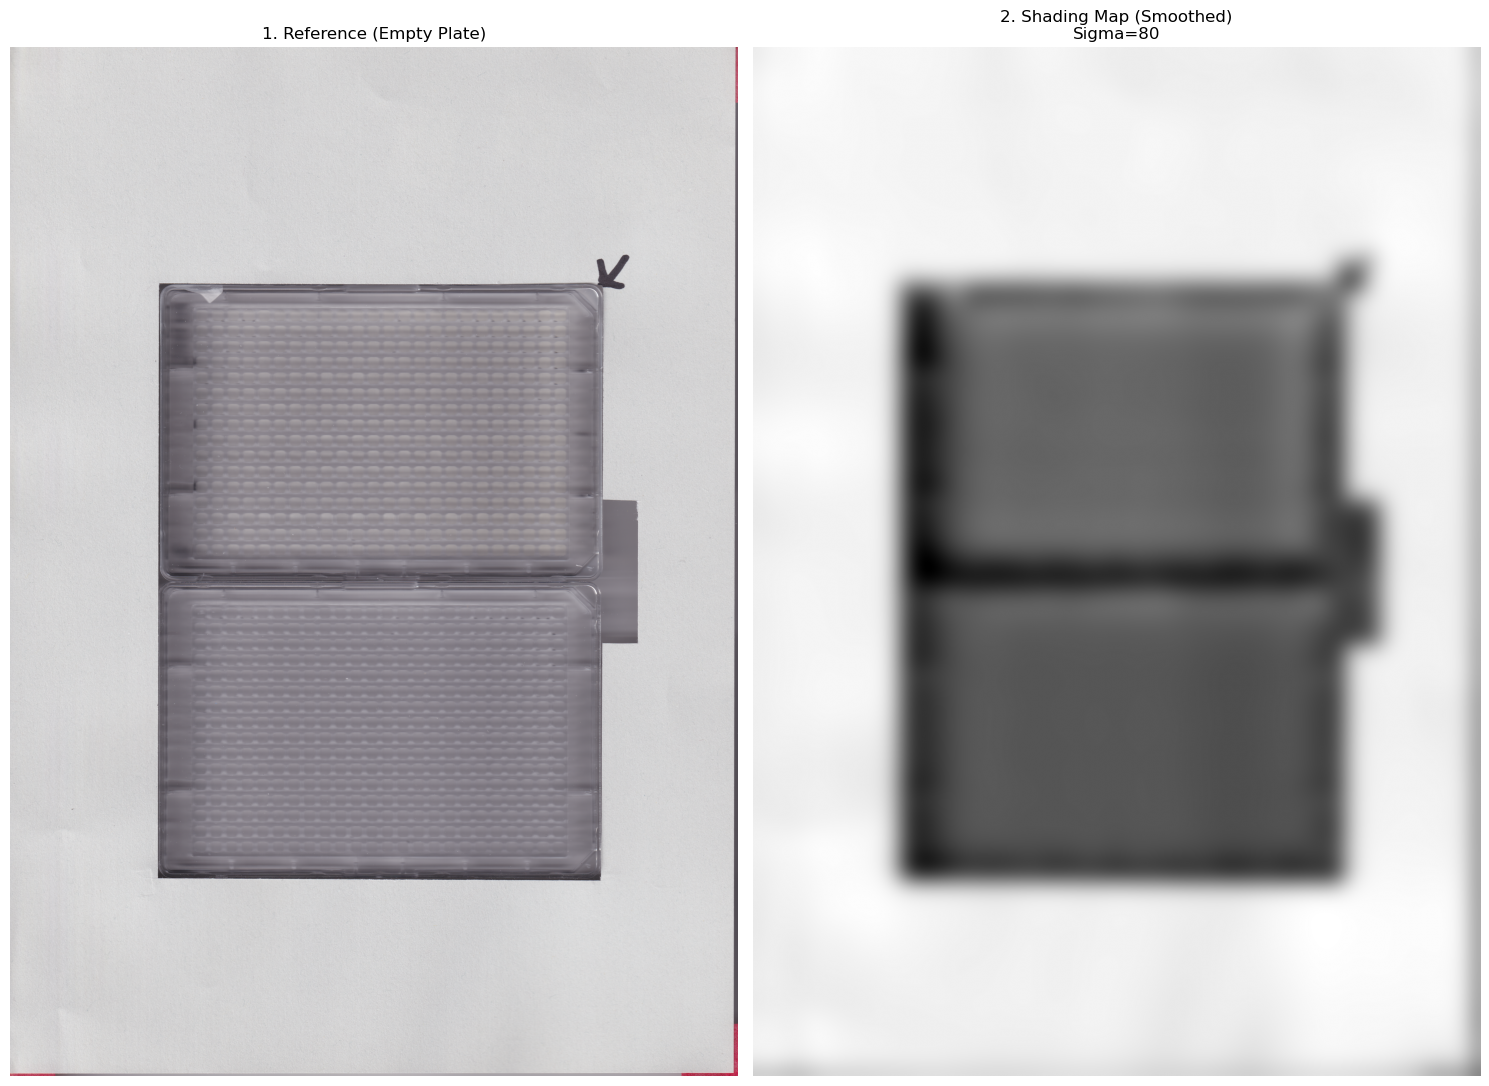

In [3]:
# --- CONFIGURATION ---
# 1. Path to your EMPTY plate scan (Media + Dry)
reference_file = '/Users/astr/Documents/Pigments/ScanQuantif/Scans/IMG_20260619_T0_empty.tif'

# 3. TUNABLE PARAMETER: Smoothing Sigma
# This controls how "blurry" the shading map is.
# - Too low: It sees the well edges and tries to correct them (bad).
# - Too high: It misses the gradient of the shadow.
# Start with 50 or 100. Adjust based on image size.
SMOOTH_SIGMA = 80 

# --- STEP 1: LOAD REFERENCE (EMPTY PLATE) ---
print("Loading Reference...")
ref_img = np.array(Image.open(reference_file)).astype(float)

# If RGB, convert to Grayscale for the shading map (light is intensity-based)
if ref_img.ndim == 3:
    # Simple luminance: 0.299*R + 0.587*G + 0.114*B
    ref_gray = np.dot(ref_img[...,:3], [0.299, 0.587, 0.114])
else:
    ref_gray = ref_img

# --- STEP 2: CREATE THE SHADING MAP ---
print(f"Generating Shading Map (Sigma={SMOOTH_SIGMA})...")
# Gaussian blur removes the high-frequency details (wells) and keeps the low-frequency shadow
shading_map = gaussian_filter(ref_gray, sigma=SMOOTH_SIGMA)

# Normalize the map so its average is 1.0
# This ensures we don't brighten/darken the whole image, just correct relative differences
shading_map = shading_map / np.mean(shading_map)

# --- STEP 4: VISUALIZE RESULTS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 12))

# 1. Original Reference
axes[0].imshow(ref_img.astype(int))
axes[0].set_title("1. Reference (Empty Plate)")
axes[0].axis('off')

# 2. The Calculated Shading Map
axes[1].imshow(shading_map, cmap='gray')
axes[1].set_title(f"2. Shading Map (Smoothed)\nSigma={SMOOTH_SIGMA}")
axes[1].axis('off')

plt.tight_layout()
plt.show()



Correcting Experimental Image...


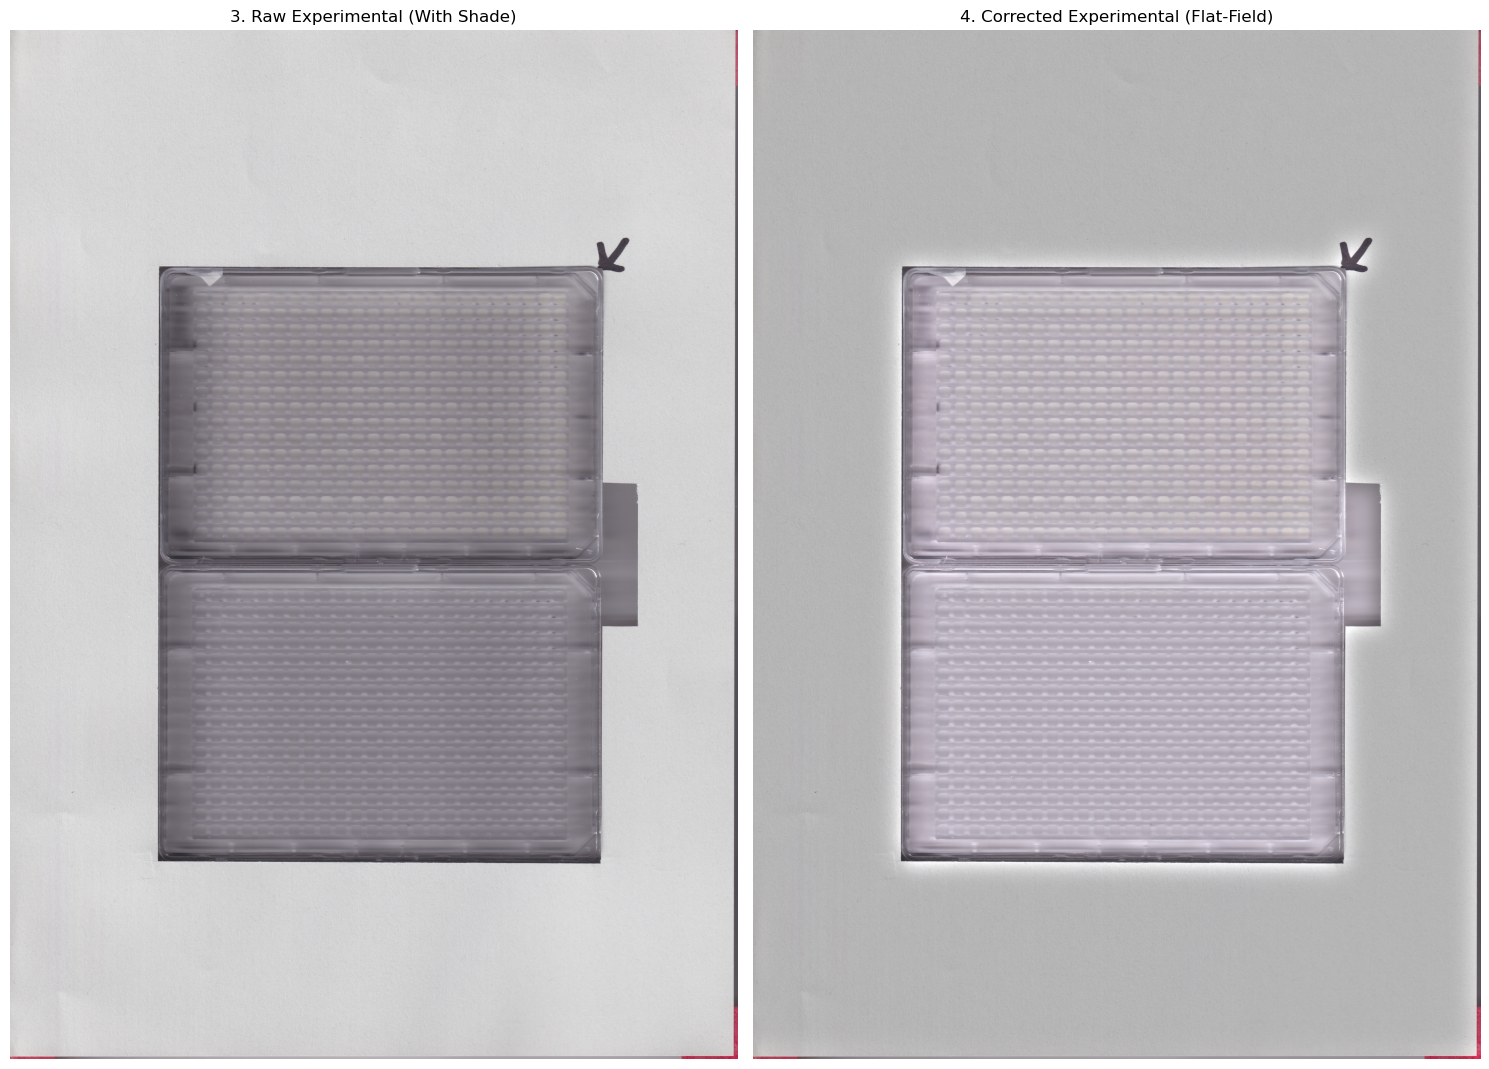

In [4]:
# 2. Path to the EXPERIMENTAL plate you want to correct
experimental_file = '/Users/astr/Documents/Pigments/ScanQuantif/Scans/IMG_20260619_T0_empty.tif' # Change this

# --- STEP 3: APPLY CORRECTION TO EXPERIMENTAL IMAGE ---
print("Correcting Experimental Image...")
exp_img = np.array(Image.open(experimental_file)).astype(float)

# We apply the correction channel-by-channel to preserve color
corrected_img = np.zeros_like(exp_img)

for c in range(3): # R, G, B
    channel = exp_img[:, :, c]
    # Formula: Corrected = Raw / Shading_Map
    # We add a tiny epsilon (1e-5) to avoid division by zero if shadow is black
    corrected_img[:, :, c] = (channel / (shading_map + 1e-5)) 

# Clip values to valid range 0-255
corrected_img = np.clip(corrected_img, 0, 255).astype(np.uint8)

# --- STEP 4: VISUALIZE RESULTS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 12))

# 3. Original Experimental
axes[0].imshow(exp_img.astype(int))
axes[0].set_title("3. Raw Experimental (With Shade)")
axes[0].axis('off')

# 4. Corrected Experimental
axes[1].imshow(corrected_img)
axes[1].set_title("4. Corrected Experimental (Flat-Field)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Correcting Experimental Image...


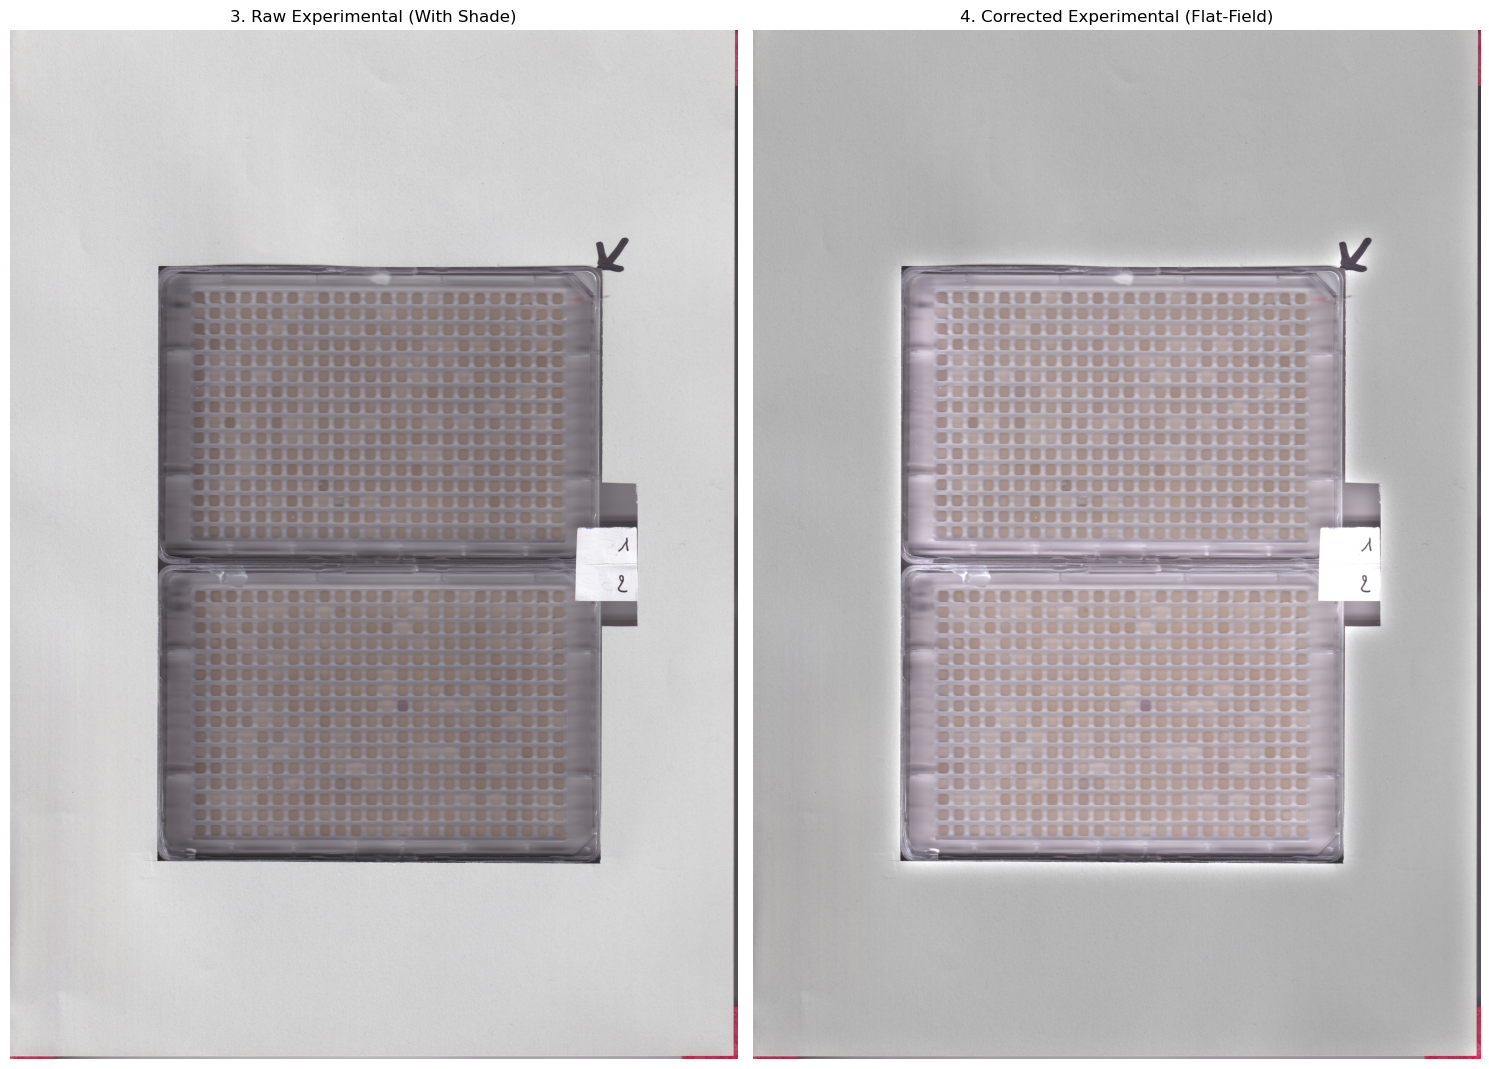

In [6]:
# 2. Path to the EXPERIMENTAL plate you want to correct
experimental_file = '/Users/astr/Documents/Pigments/ScanQuantif/Scans/IMG_20260617_Red_12.tif' # Change this

# --- STEP 3: APPLY CORRECTION TO EXPERIMENTAL IMAGE ---
print("Correcting Experimental Image...")
exp_img = np.array(Image.open(experimental_file)).astype(float)

# We apply the correction channel-by-channel to preserve color
corrected_img = np.zeros_like(exp_img)

for c in range(3): # R, G, B
    channel = exp_img[:, :, c]
    # Formula: Corrected = Raw / Shading_Map
    # We add a tiny epsilon (1e-5) to avoid division by zero if shadow is black
    corrected_img[:, :, c] = (channel / (shading_map + 1e-5)) 

# Clip values to valid range 0-255
corrected_img = np.clip(corrected_img, 0, 255).astype(np.uint8)

# --- STEP 4: VISUALIZE RESULTS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 12))

# 3. Original Experimental
axes[0].imshow(exp_img.astype(int))
axes[0].set_title("3. Raw Experimental (With Shade)")
axes[0].axis('off')

# 4. Corrected Experimental
axes[1].imshow(corrected_img)
axes[1].set_title("4. Corrected Experimental (Flat-Field)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# --- STEP 5: SAVE CORRECTED IMAGE ---
output_path = experimental_file.replace('.tif', '_CORRECTED.tif')
Image.fromarray(corrected_img).save(output_path)
print(f"Saved corrected image to: {output_path}")

# --- DIAGNOSTIC: Check the corners vs center ---
h, w = shading_map.shape
center_val = shading_map[h//2, w//2]
corner_val = shading_map[50, 50] # Approximate corner
print(f"\nDiagnostic:")
print(f"Center Intensity (normalized): {center_val:.2f}")
print(f"Corner Intensity (normalized): {corner_val:.2f}")
print(f"Correction Factor needed at corners: {1/corner_val:.2f}x")

In [7]:
def apply_shade_correction(experimental_file, shading_map, show_plot=True):
    """
    Applies a pre-calculated shading map to an experimental image.
    
    Parameters:
    - experimental_file: Path to the raw image (.tif, .png, etc.)
    - shading_map: The normalized 2D numpy array (grayscale) generated from the empty plate.
    - show_plot: If True, displays a side-by-side comparison (Raw vs Corrected).
    
    Returns:
    - corrected_img: The corrected image as a numpy array (uint8).
    """
    # 1. Load Image
    exp_img = np.array(Image.open(experimental_file)).astype(float)
    
    # 2. Apply Correction Channel-by-Channel
    corrected_img = np.zeros_like(exp_img)
    
    # Ensure shading_map has 2 dimensions (H, W)
    if shading_map.ndim != 2:
        raise ValueError("shading_map must be a 2D grayscale array.")
        
    # Check dimensions match
    if exp_img.shape[:2] != shading_map.shape:
        # Optional: Resize shading_map if images differ slightly, but better to throw error
        raise ValueError(f"Image shape {exp_img.shape[:2]} does not match shading map {shading_map.shape}")

    for c in range(3): # R, G, B
        channel = exp_img[:, :, c]
        # Formula: Corrected = Raw / Shading_Map
        corrected_img[:, :, c] = (channel / (shading_map + 1e-5)) 
    
    # 3. Clip and Convert to Uint8
    corrected_img = np.clip(corrected_img, 0, 255).astype(np.uint8)
    
    # 4. Optional Plot
    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        axes[0].imshow(exp_img.astype(int))
        axes[0].set_title("Raw Experimental", fontsize=14)
        axes[0].axis('off')
        
        axes[1].imshow(corrected_img)
        axes[1].set_title("Corrected (Flat-Field)", fontsize=14)
        axes[1].axis('off')
        
        plt.suptitle(f"File: {experimental_file}", fontsize=12, y=1.05)
        plt.tight_layout()
        plt.show()
    
    return corrected_img

In [9]:
# --- CONFIGURATION ---
# Folder where your scans are located
scan_folder = '/Users/astr/Documents/Pigments/ScanQuantif/Scans/'

# Pattern to find files (e.g., all .tif files)
# You can make this specific, e.g., '*Red*.tif' if you only want Red plates
file_pattern = os.path.join(scan_folder, '*0617_Red*.tif') 

# Get list of all matching files
all_files = glob.glob(file_pattern)

# Filter: Remove the reference image and any already corrected images
files_to_correct = [
    f for f in all_files 
    if ('_CORRECTED.tif' not in f) and ('T0_empty' not in f)
]

print(f"Found {len(files_to_correct)} images to process.")

# --- LOOP AND PROCESS ---
corrected_files_list = []

for file_path in files_to_correct:
    filename = os.path.basename(file_path)
    print(f"Processing: {filename}...")
    
    try:
        # 1. Apply Correction (show_plot=False for speed)
        corrected_img = apply_shade_correction(file_path, shading_map, show_plot=False)
        
        # 2. Define Output Path (add '_CORRECTED' before extension)
        base_name, ext = os.path.splitext(file_path)
        output_path = f"{base_name}_CORRECTED{ext}"
        
        # 3. Save
        Image.fromarray(corrected_img).save(output_path)
        corrected_files_list.append(output_path)
        
        print(f"  -> Saved: {os.path.basename(output_path)}")
        
    except Exception as e:
        print(f"  -> ERROR processing {filename}: {e}")

print("\n--- Batch Complete ---")
print(f"Successfully corrected {len(corrected_files_list)} images.")

Found 3 images to process.
Processing: IMG_20260617_Red_12.tif...
  -> Saved: IMG_20260617_Red_12_CORRECTED.tif
Processing: IMG_20260617_Red_67.tif...
  -> Saved: IMG_20260617_Red_67_CORRECTED.tif
Processing: IMG_20260617_Red_35.tif...
  -> Saved: IMG_20260617_Red_35_CORRECTED.tif

--- Batch Complete ---
Successfully corrected 3 images.


# Extract RGB

In [4]:
def extract_and_save_plate_colors(image_array, plate_corners_list, output_dir, file_prefix, nRows=16, nCols=24, rad=10):
    """
    Extracts RGB values from wells and saves them as CSV files.
    
    Parameters:
    - image_array: numpy array of the image (H, W, 3). Should be flat-field corrected.
    - plate_corners_list: List of corner arrays. e.g., [PlateA, PlateB]
    - output_dir: Path to the folder where CSVs will be saved.
    - file_prefix: String to start the filename (e.g., 'D2Ext', 'Blank').
    - nRows, nCols: Grid dimensions (default 16x24).
    - rad: Radius of the well mask in pixels.
    
    Returns:
    - AllPlateColors: List of numpy arrays (16x24x3) for further processing.
    """
    
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    AllPlateColors = []
    channels = ['R', 'G', 'B']
    
    print(f"Starting extraction for {len(plate_corners_list)} plate(s)...")

    for pi, corners in enumerate(plate_corners_list):
        # 1. Get Grid Coordinates
        X, Y = getAllCenters(corners, nRows, nCols)
        x_coords = X.flatten().astype(int)
        y_coords = Y.flatten().astype(int)
        
        # 2. Initialize storage
        well_colors = np.zeros((nRows * nCols, 3))
        
        # 3. Extract colors for each well
        for i in range(len(x_coords)):
            cx, cy = x_coords[i], y_coords[i]
            
            # Bounding box with safety checks
            y_min = max(0, cy - rad)
            y_max = min(image_array.shape[0], cy + rad + 1)
            x_min = max(0, cx - rad)
            x_max = min(image_array.shape[1], cx + rad + 1)
            
            region = image_array[y_min:y_max, x_min:x_max]
            
            # Relative center
            center_y_rel = cy - y_min
            center_x_rel = cx - x_min
            
            # Dynamic Circular Mask
            h_reg, w_reg, _ = region.shape
            y_reg, x_reg = np.ogrid[:h_reg, :w_reg]
            dist_sq = (x_reg - center_x_rel)**2 + (y_reg - center_y_rel)**2
            mask = dist_sq <= rad**2
            
            if np.any(mask):
                well_colors[i] = np.mean(region[mask], axis=0)
            else:
                well_colors[i] = [0, 0, 0]
        
        # Reshape to (16, 24, 3) and store
        colors_plate = well_colors.reshape(nRows, nCols, 3)
        AllPlateColors.append(colors_plate)
        print(f"  -> Plate {pi+1} extracted.")

    # 4. Save CSVs
    print("Saving CSV files...")
    for p, colors_data in enumerate(AllPlateColors):
        for c_idx, ch in enumerate(channels):
            data = colors_data[:, :, c_idx]
            # Filename format: prefix_Plate1_R.csv
            filename = f"{file_prefix}_Plate{p+1}_{ch}.csv"
            filepath = os.path.join(output_dir, filename)
            
            pd.DataFrame(data).to_csv(filepath, index=False, header=False)
    
    print(f"Extraction complete. Saved {len(plate_corners_list)*3} files to {output_dir}")
    return AllPlateColors

In [12]:
# --- 1. Load your Corrected Image ---
picF = '/Users/astr/Documents/Pigments/ScanQuantif/Scans/IMG_20260617_Red_12_CORRECTED.tif'
# If you have a corrected version, load that instead!
# picF = '/Users/astr/Documents/Pigments/ScanQuantif/Scans/IMG_20260622_Vio_Red_D2Ext_CORRECTED.tif'

im = np.array(Image.open(picF))

# --- 2. Define Corners ---
PlateA = np.array([[1272,1824], [1284,3444], [3720,1836], [3720,3444]])
PlateB = np.array([[1284,3864], [1284,5472], [3744,3864], [3744,5472]]) #Red12
allPlates = [PlateA, PlateB]

# --- 3. Run the Function ---
# Make sure getAllCenters is defined in your session before running this!
output_folder = '/Users/astr/Documents/Pigments/ScanQuantif'
file_name_prefix = '0617_Red_12' # Changes the start of the CSV filename

AllPlateColors = extract_and_save_plate_colors(
    image_array=im, 
    plate_corners_list=allPlates, 
    output_dir=output_folder, 
    file_prefix=file_name_prefix,
    rad=10 # You can adjust radius here easily
)

print("Done! You can now load the CSVs for contrast enhancement.")

Starting extraction for 2 plate(s)...
  -> Plate 1 extracted.
  -> Plate 2 extracted.
Saving CSV files...
Extraction complete. Saved 6 files to /Users/astr/Documents/Pigments/ScanQuantif
Done! You can now load the CSVs for contrast enhancement.


# Increase RED contrast

# Plotting set-up


/var/folders/cv/fwqxrhps4xd4f5w0mqjgh3780000gp/T/ipykernel_19212/3437478768.py:135: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Group', loc='upper right')


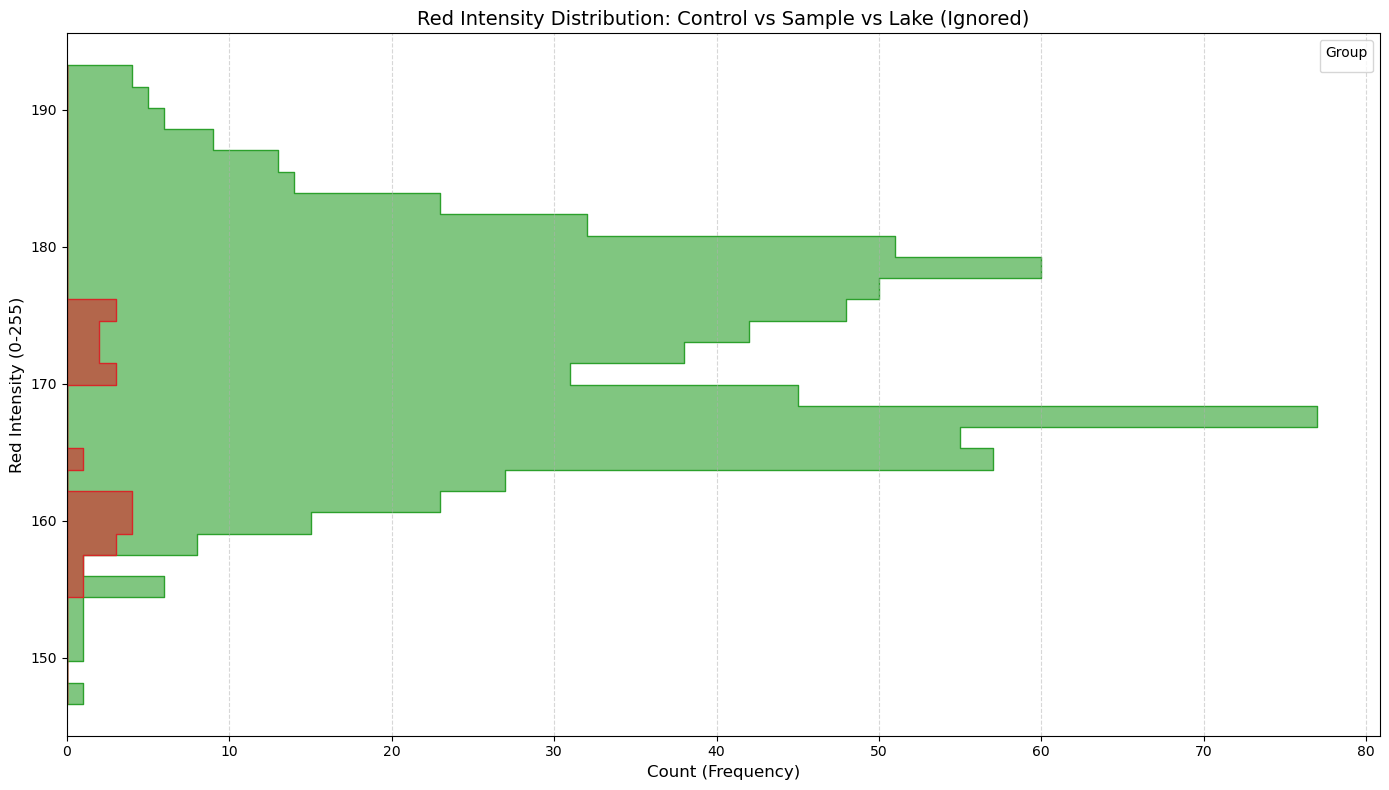


=== Group Statistics ===
         count        mean       std         min         25%         50%  \
Group                                                                      
Control   24.0  165.234621  6.933354  154.634069  160.057571  161.681388   
Sample   744.0  172.527840  7.768412  146.627760  166.653785  172.384858   

                75%         max  
Group                            
Control  171.905363  175.167192  
Sample   178.384858  193.249211  

=== Well Counts ===
Group
Sample     744
Control     24
Name: count, dtype: int64


In [ ]:
# --- CONFIGURATION: Define Layout Rules Here ---

def make_tags_rule(layout_type):
    """
    Generates a tag array (length 384) based on the layout type.
    Tags: 1 = Control, 0 = Sample, 2 = Lake (Ignore)
    """
    tags = np.full(384, 2, dtype=int) # Default ALL to 2 (Lake/Ignore)
    
    if layout_type == 'type_A': 
        # First line, even starting at 0 (Indices 0, 2, 4... 22)
        tags[:] = 0 # Reset rest to Sample
        tags[0:24:2] = 1 
        
    elif layout_type == 'type_B':
        # 2 first full lines (Indices 0 to 47)
        tags[:] = 0 # Reset rest to Sample
        tags[0:48] = 1
        
    elif layout_type == 'type_C':
        # First line full (0-23) AND Line 2 even starting at 0 (24, 26...)
        tags[:] = 0 # Reset rest to Sample
        tags[0:24] = 1
        tags[24:48:2] = 1
        
    elif layout_type == 'type_D':
        # First full line ONLY = Control. 
        # The rest REMAINS 2 (Lake/Ignore) because we initialized with 2.
        tags[0:24] = 1
        
    elif layout_type == 'type_E':
        # Example: All wells are samples (no controls)
        tags[:] = 0 
        
    return tags

# Map your specific plates to these rules
# UPDATE THIS DICTIONARY WITH YOUR ACTUAL FILE PREFIXES
plate_layouts = {
    '0617_Red_12_Plate1': 'type_A',
    '0617_Red_12_Plate2': 'type_A',
    # Add your other scans here as you load them
    # 'Scan2_PlateA': 'type_A', 
    # 'Scan2_PlateB': 'type_B',
    # 'Scan3_PlateA': 'type_C',
    # 'Scan3_PlateB': 'type_D', 
}

# --- FUNCTION TO LOAD & TAG ---
def load_and_tag_plate(file_prefix, plate_num, layout_map, data_dir):
    key = f"{file_prefix}_Plate{plate_num}"
    
    if key not in layout_map:
        print(f"Warning: No layout defined for {key}. Skipping.")
        return None
        
    rule = layout_map[key]
    tags = make_tags_rule(rule)
    
    # Load Data (Assuming R, G, B files exist)
    try:
        df_r = pd.read_csv(f"{data_dir}/{key}_R.csv", header=None).to_numpy().flatten()
        df_g = pd.read_csv(f"{data_dir}/{key}_G.csv", header=None).to_numpy().flatten()
        df_b = pd.read_csv(f"{data_dir}/{key}_B.csv", header=None).to_numpy().flatten()

    except FileNotFoundError as e:
        print(f"Error: Could not find files for {key}. {e}")
        return None
    
    # Combine into one long DataFrame
    data = {
        'Value': np.concatenate([df_r, df_g, df_b]),
        'Channel': ['R']*384 + ['G']*384 + ['B']*384,
        'Tag': np.concatenate([tags, tags, tags]),
        'Plate': key
    }
    
    df = pd.DataFrame(data)
    
    # Map Tags to Readable Names
    df['Group'] = df['Tag'].map({
        1: 'Control', 
        0: 'Sample', 
        2: 'Lake' # The ignored wells
    })
    
    return df

# --- EXECUTION ---
data_directory = '/Users/astr/Documents/Pigments/ScanQuantif'
all_data = []

# Example Loop: Update the range and prefix to match your actual files
# For now, let's simulate loading the defined plates in the dictionary
for key in plate_layouts.keys():
    # Parse key to get prefix and plate number (Simple parser for 'Prefix_PlateN')
    parts = key.rsplit('_Plate', 1)
    if len(parts) == 2:
        prefix = parts[0]
        p_num = parts[1] # Keeps '1', '2', 'A', 'B' etc.
        
        df = load_and_tag_plate(prefix, p_num, plate_layouts, data_directory)
        if df is not None:
            all_data.append(df)

if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    
    # --- PLOT: 3 Groups (Control, Sample, Lake) ---
    plt.figure(figsize=(14, 8))
    
    # Define specific colors for clarity
    custom_palette = {
        'Control': '#d62728', # Red
        'Sample': '#2ca02c',  # Green
        'Lake': '#7f7f7f'     # Gray
    }
    
    # Plot
    sns.histplot(
        data=final_df, 
        y='Value', 
        hue='Group', 
        bins=30, 
        alpha=0.6, 
        element='step',
        palette=custom_palette,
        multiple='layer' # Overlap them to see distribution shifts
    )
    
    plt.title('Red Intensity Distribution: Control vs Sample vs Lake (Ignored)', fontsize=14)
    plt.xlabel('Count (Frequency)', fontsize=12)
    plt.ylabel('Red Intensity (0-255)', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.legend(title='Group', loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # --- STATS ---
    print("\n=== Group Statistics ===")
    print(final_df.groupby('Group')['Value'].describe())
    
    # Optional: Check how many wells are in each group
    print("\n=== Well Counts ===")
    print(final_df['Group'].value_counts())

else:
    print("No data loaded. Check your `plate_layouts` keys and file paths.")

Euria : I also added a small helper to calculate OD automatically within the plot loop, so you can see both the Raw Intensity and the Optical Density for each channel side-by-side. This will clearly demonstrate why the Green channel is likely better for your red pigment. 
Plus plots separately R G and B channels.

/var/folders/cv/fwqxrhps4xd4f5w0mqjgh3780000gp/T/ipykernel_19212/43923998.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Group', loc='upper right')


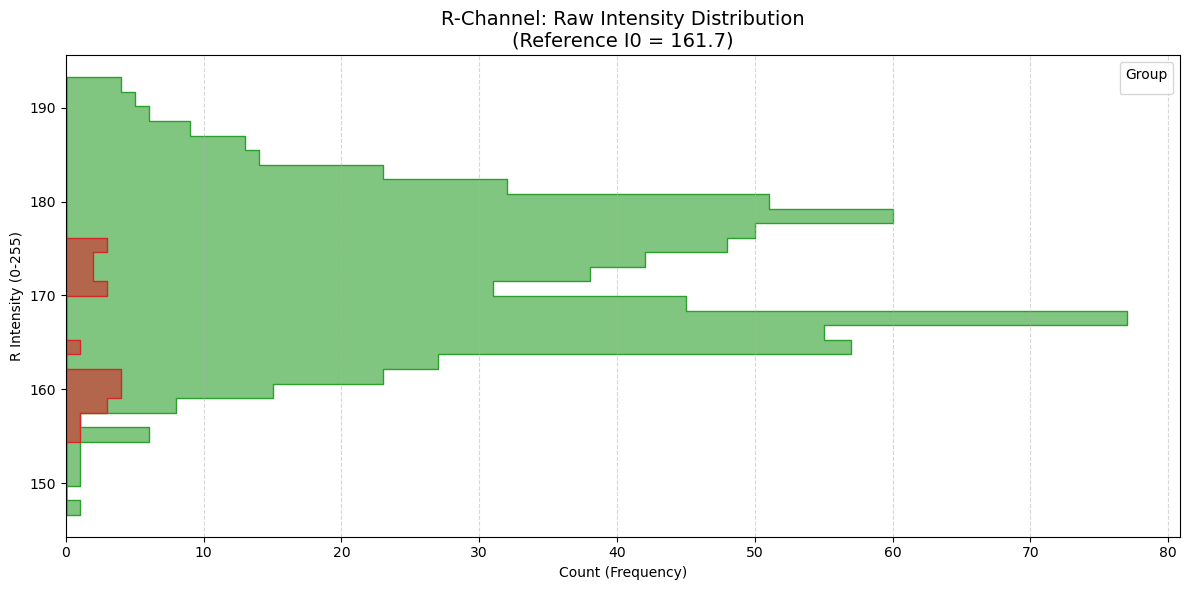

/var/folders/cv/fwqxrhps4xd4f5w0mqjgh3780000gp/T/ipykernel_19212/43923998.py:157: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Group', loc='upper right')


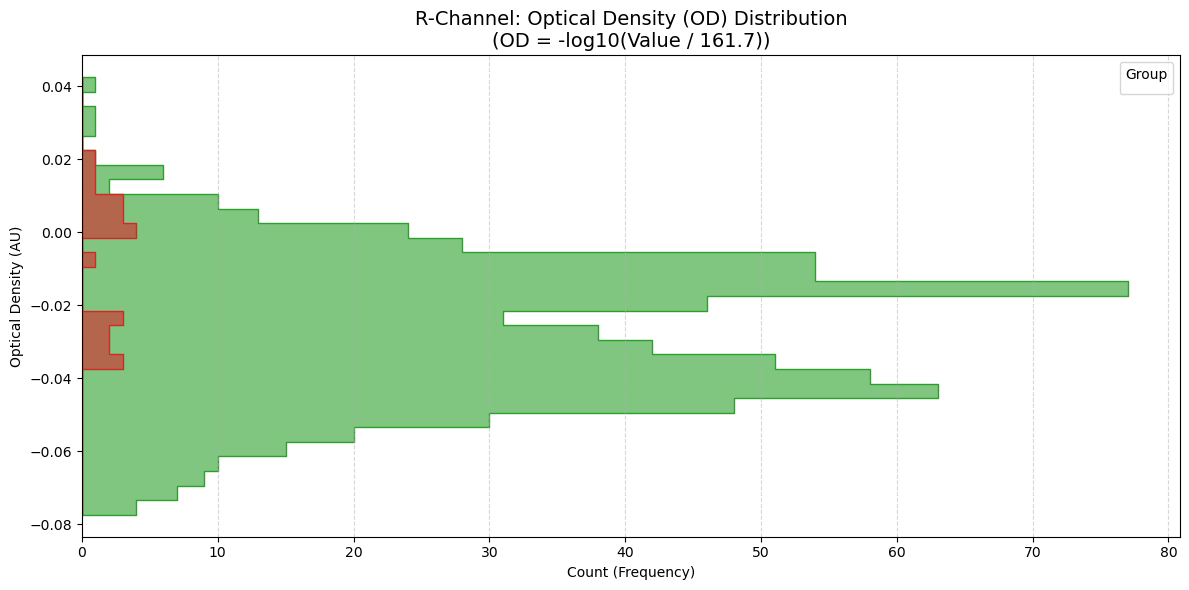


=== R-Channel Statistics ===
Raw Intensity:
               mean       std
Group                        
Control  165.234621  6.933354
Sample   172.527840  7.768412

Optical Density (OD):
             mean       std
Group                      
Control -0.009076  0.018173
Sample  -0.027759  0.019559
------------------------------


/var/folders/cv/fwqxrhps4xd4f5w0mqjgh3780000gp/T/ipykernel_19212/43923998.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Group', loc='upper right')


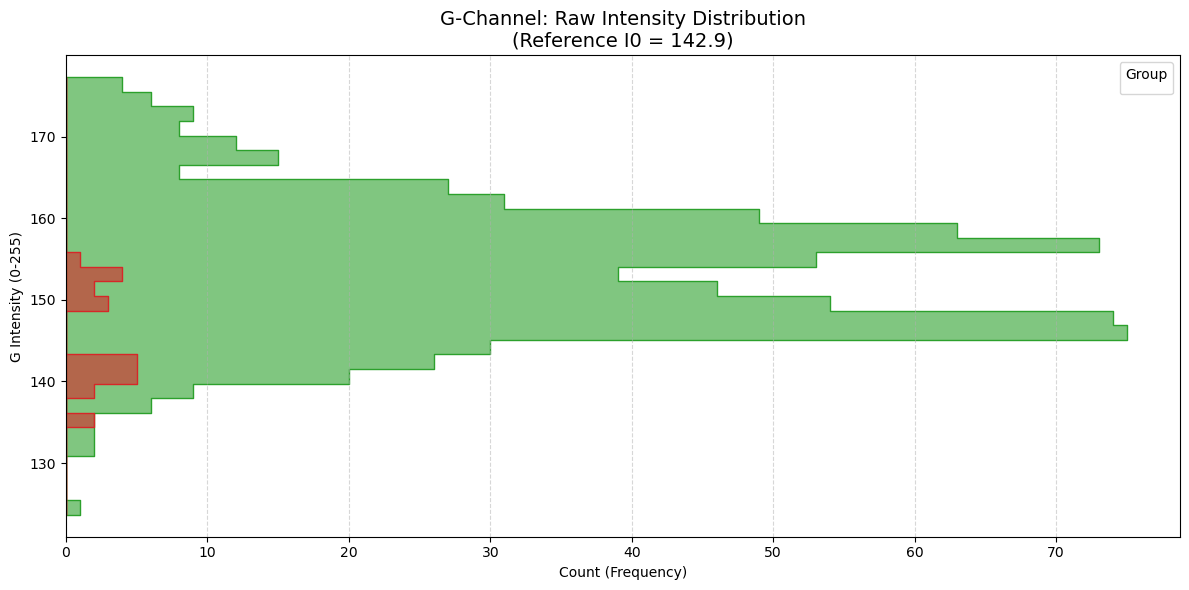

/var/folders/cv/fwqxrhps4xd4f5w0mqjgh3780000gp/T/ipykernel_19212/43923998.py:157: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Group', loc='upper right')


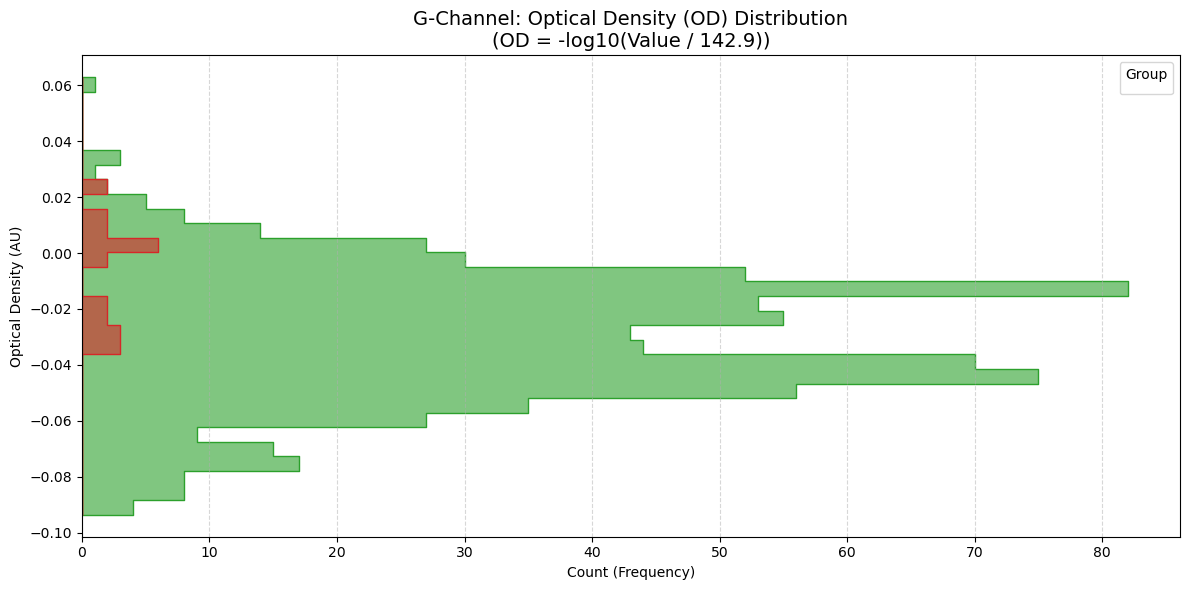


=== G-Channel Statistics ===
Raw Intensity:
               mean       std
Group                        
Control  145.245531  6.248909
Sample   153.545105  8.293471

Optical Density (OD):
             mean       std
Group                      
Control -0.006646  0.018652
Sample  -0.030534  0.023388
------------------------------


/var/folders/cv/fwqxrhps4xd4f5w0mqjgh3780000gp/T/ipykernel_19212/43923998.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Group', loc='upper right')


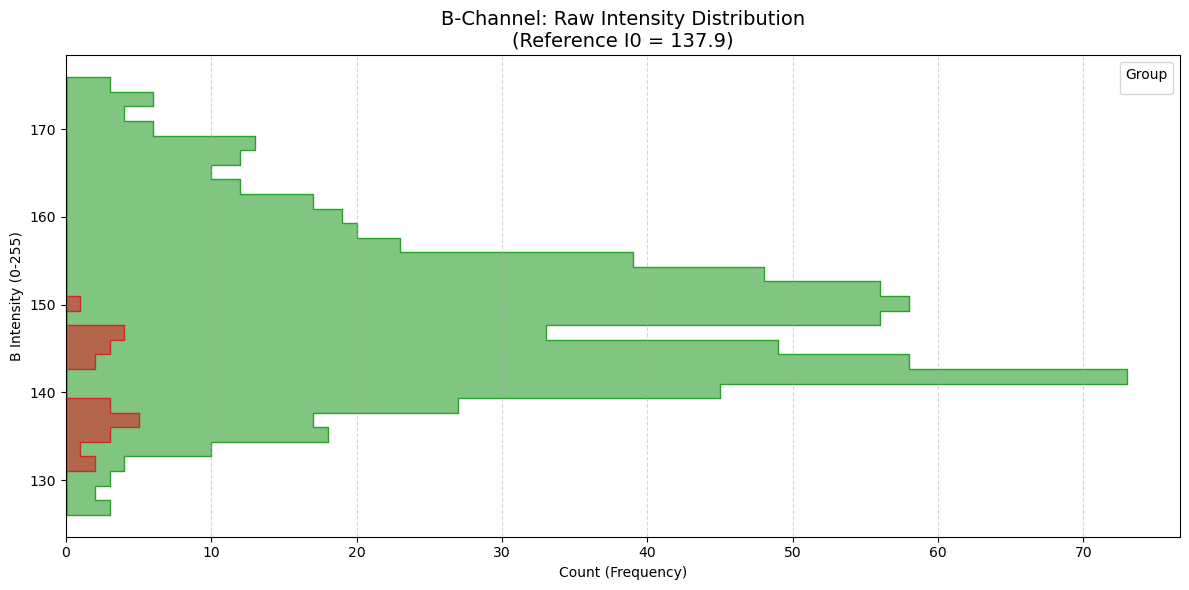

/var/folders/cv/fwqxrhps4xd4f5w0mqjgh3780000gp/T/ipykernel_19212/43923998.py:157: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Group', loc='upper right')


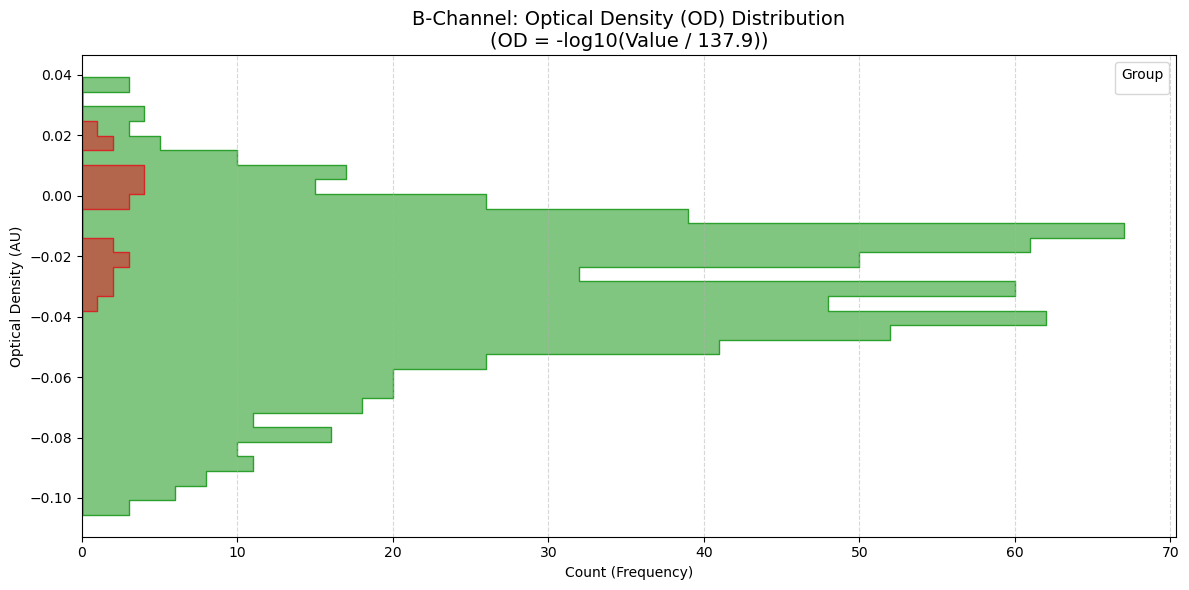


=== B-Channel Statistics ===
Raw Intensity:
               mean       std
Group                        
Control  140.014590  5.535149
Sample   149.082218  9.028928

Optical Density (OD):
             mean       std
Group                      
Control -0.006154  0.017108
Sample  -0.032946  0.026031
------------------------------


In [6]:
# --- CONFIGURATION: Define Layout Rules Here ---

def make_tags_rule(layout_type):
    """
    Generates a tag array (length 384) based on the layout type.
    Tags: 1 = Control, 0 = Sample, 2 = Lake (Ignore)
    """
    tags = np.full(384, 2, dtype=int) # Default ALL to 2 (Lake/Ignore)
    
    if layout_type == 'type_A': 
        # First line, even starting at 0 (Indices 0, 2, 4... 22)
        tags[:] = 0 # Reset rest to Sample
        tags[0:24:2] = 1 
        
    elif layout_type == 'type_B':
        # 2 first full lines (Indices 0 to 47)
        tags[:] = 0 # Reset rest to Sample
        tags[0:48] = 1
        
    elif layout_type == 'type_C':
        # First line full (0-23) AND Line 2 even starting at 0 (24, 26...)
        tags[:] = 0 # Reset rest to Sample
        tags[0:24] = 1
        tags[24:48:2] = 1
        
    elif layout_type == 'type_D':
        # First full line ONLY = Control. 
        # The rest REMAINS 2 (Lake/Ignore) because we initialized with 2.
        tags[0:24] = 1
        
    elif layout_type == 'type_E':
        # Example: All wells are samples (no controls)
        tags[:] = 0 
        
    return tags

# Map your specific plates to these rules
# UPDATE THIS DICTIONARY WITH YOUR ACTUAL FILE PREFIXES
plate_layouts = {
    '0617_Red_12_Plate1': 'type_A',
    '0617_Red_12_Plate2': 'type_A',
    # Add your other scans here as you load them
    # 'Scan2_PlateA': 'type_A', 
    # 'Scan2_PlateB': 'type_B',
    # 'Scan3_PlateA': 'type_C',
    # 'Scan3_PlateB': 'type_D', 
}

# --- CONFIGURATION (Keep your existing definitions) ---
# Ensure make_tags_rule and plate_layouts are defined as before...
# (Assuming they are already in your session from previous steps)

# --- FUNCTION TO LOAD & TAG (Unchanged: Loads R, G, B) ---
def load_and_tag_plate(file_prefix, plate_num, layout_map, data_dir):
    key = f"{file_prefix}_Plate{plate_num}"
    
    if key not in layout_map:
        return None
        
    rule = layout_map[key]
    tags = make_tags_rule(rule)
    
    try:
        df_r = pd.read_csv(f"{data_dir}/{key}_R.csv", header=None).to_numpy().flatten()
        df_g = pd.read_csv(f"{data_dir}/{key}_G.csv", header=None).to_numpy().flatten()
        df_b = pd.read_csv(f"{data_dir}/{key}_B.csv", header=None).to_numpy().flatten()
    except FileNotFoundError:
        return None
    
    # Combine data
    data = {
        'Value': np.concatenate([df_r, df_g, df_b]),
        'Channel': ['R']*384 + ['G']*384 + ['B']*384,
        'Tag': np.concatenate([tags, tags, tags]),
        'Plate': key
    }
    
    df = pd.DataFrame(data)
    df['Group'] = df['Tag'].map({1: 'Control', 0: 'Sample', 2: 'Lake'})
    return df

# --- EXECUTION: LOAD DATA ---
data_directory = '/Users/astr/Documents/Pigments/ScanQuantif'
all_data = []

for key in plate_layouts.keys():
    parts = key.rsplit('_Plate', 1)
    if len(parts) == 2:
        prefix = parts[0]
        p_num = parts[1]
        df = load_and_tag_plate(prefix, p_num, plate_layouts, data_directory)
        if df is not None:
            all_data.append(df)

if not all_data:
    print("No data loaded. Check paths and layout definitions.")
else:
    final_df = pd.concat(all_data, ignore_index=True)
    
    # Define Colors
    custom_palette = {'Control': '#d62728', 'Sample': '#2ca02c', 'Lake': '#7f7f7f'}
    channels_to_plot = ['R', 'G', 'B']
    
    # --- LOOP: PLOT EACH CHANNEL SEPARATELY ---
    for ch in channels_to_plot:
        # Filter data for current channel
        df_ch = final_df[final_df['Channel'] == ch].copy()
        
        # Calculate Reference (I0) for OD conversion
        # Use the median of Controls for this specific channel
        controls = df_ch[df_ch['Group'] == 'Control']['Value']
        if len(controls) > 0:
            i0 = controls.median()
        else:
            i0 = 255 # Fallback if no controls found
            
        # Calculate OD: -log10(Value / I0)
        epsilon = 1e-6
        df_ch['OD'] = -np.log10((df_ch['Value'] + epsilon) / (i0 + epsilon))
        
        # --- FIGURE 1: RAW INTENSITY ---
        plt.figure(figsize=(12, 6))
        sns.histplot(
            data=df_ch, 
            y='Value', 
            hue='Group', 
            bins=30, 
            alpha=0.6, 
            element='step',
            palette=custom_palette,
            multiple='layer'
        )
        plt.title(f'{ch}-Channel: Raw Intensity Distribution\n(Reference I0 = {i0:.1f})', fontsize=14)
        plt.xlabel('Count (Frequency)')
        plt.ylabel(f'{ch} Intensity (0-255)')
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.legend(title='Group', loc='upper right')
        plt.tight_layout()
        plt.show()
        
        # --- FIGURE 2: OPTICAL DENSITY (OD) ---
        plt.figure(figsize=(12, 6))
        sns.histplot(
            data=df_ch, 
            y='OD', 
            hue='Group', 
            bins=30, 
            alpha=0.6, 
            element='step',
            palette=custom_palette,
            multiple='layer'
        )
        plt.title(f'{ch}-Channel: Optical Density (OD) Distribution\n(OD = -log10(Value / {i0:.1f}))', fontsize=14)
        plt.xlabel('Count (Frequency)')
        plt.ylabel('Optical Density (AU)')
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.legend(title='Group', loc='upper right')
        plt.tight_layout()
        plt.show()
        
        # --- PRINT STATS FOR THIS CHANNEL ---
        print(f"\n=== {ch}-Channel Statistics ===")
        print("Raw Intensity:")
        print(df_ch.groupby('Group')['Value'].describe()[['mean', 'std']])
        print("\nOptical Density (OD):")
        print(df_ch.groupby('Group')['OD'].describe()[['mean', 'std']])
        print("-" * 30)

We can observe a bimodal distribution on all channels. Let's explore where this could come from... 

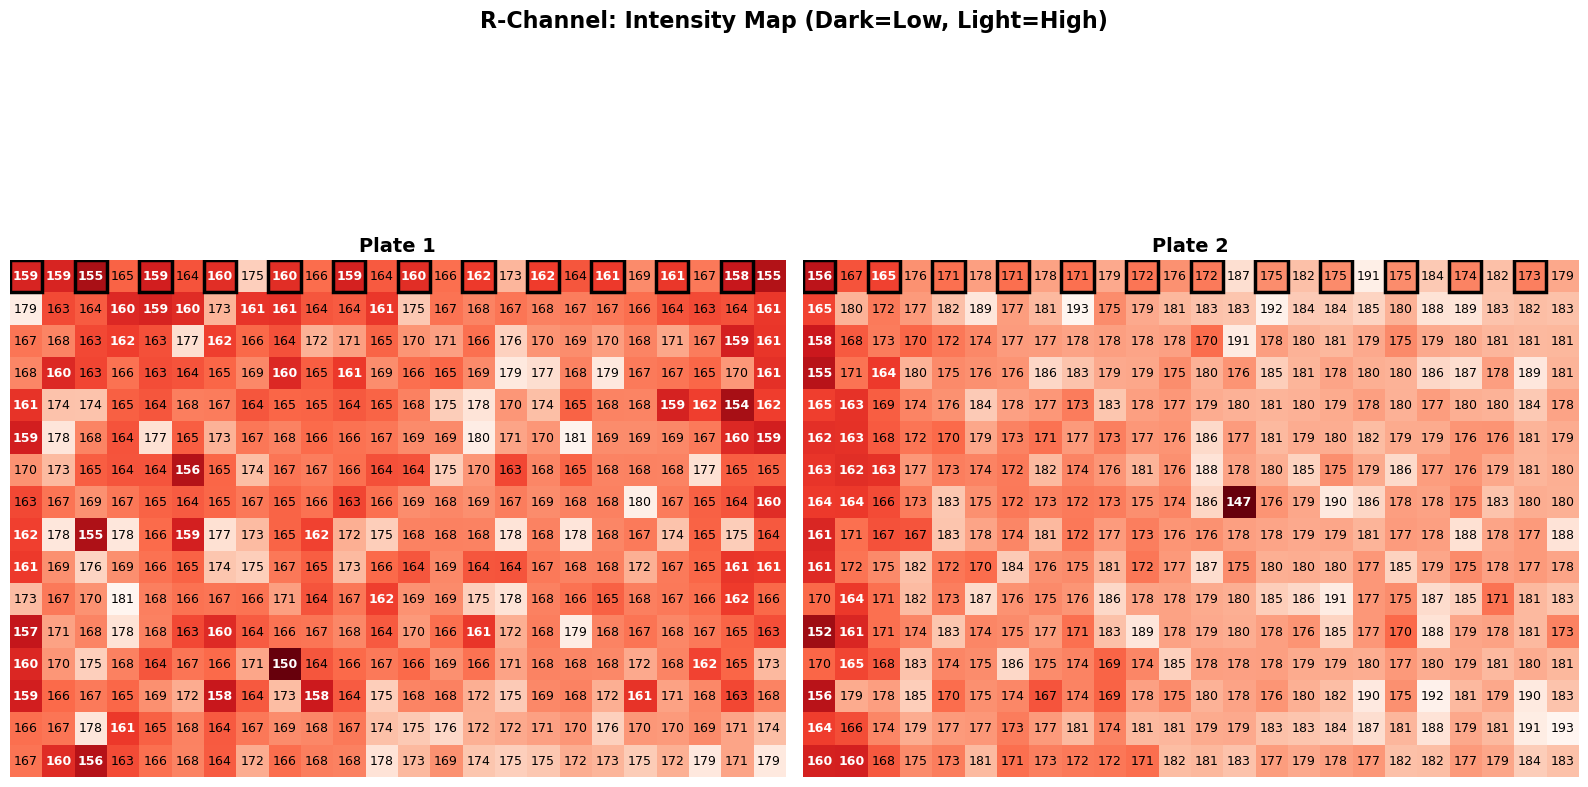

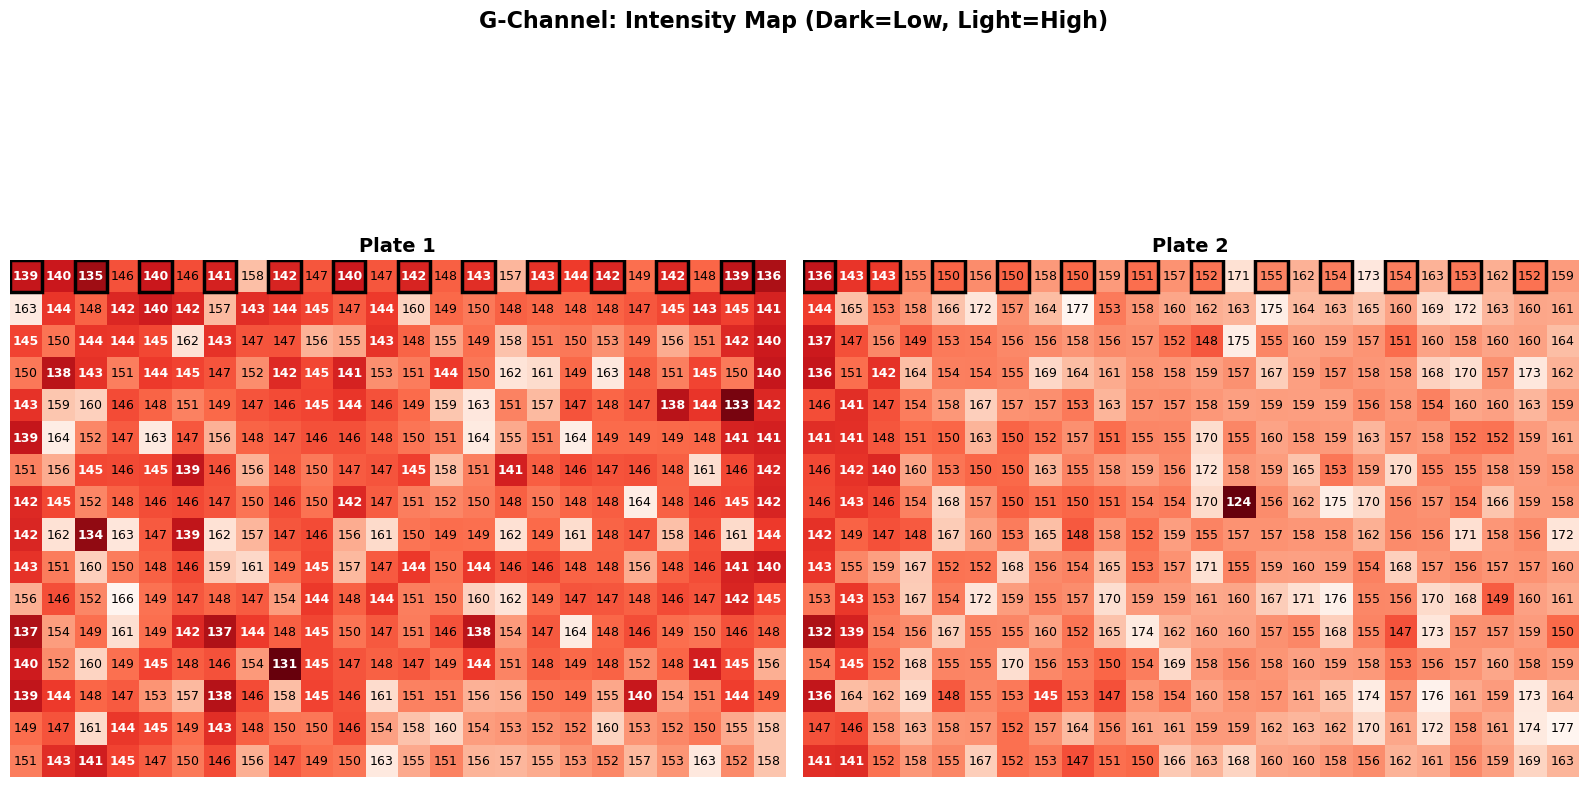

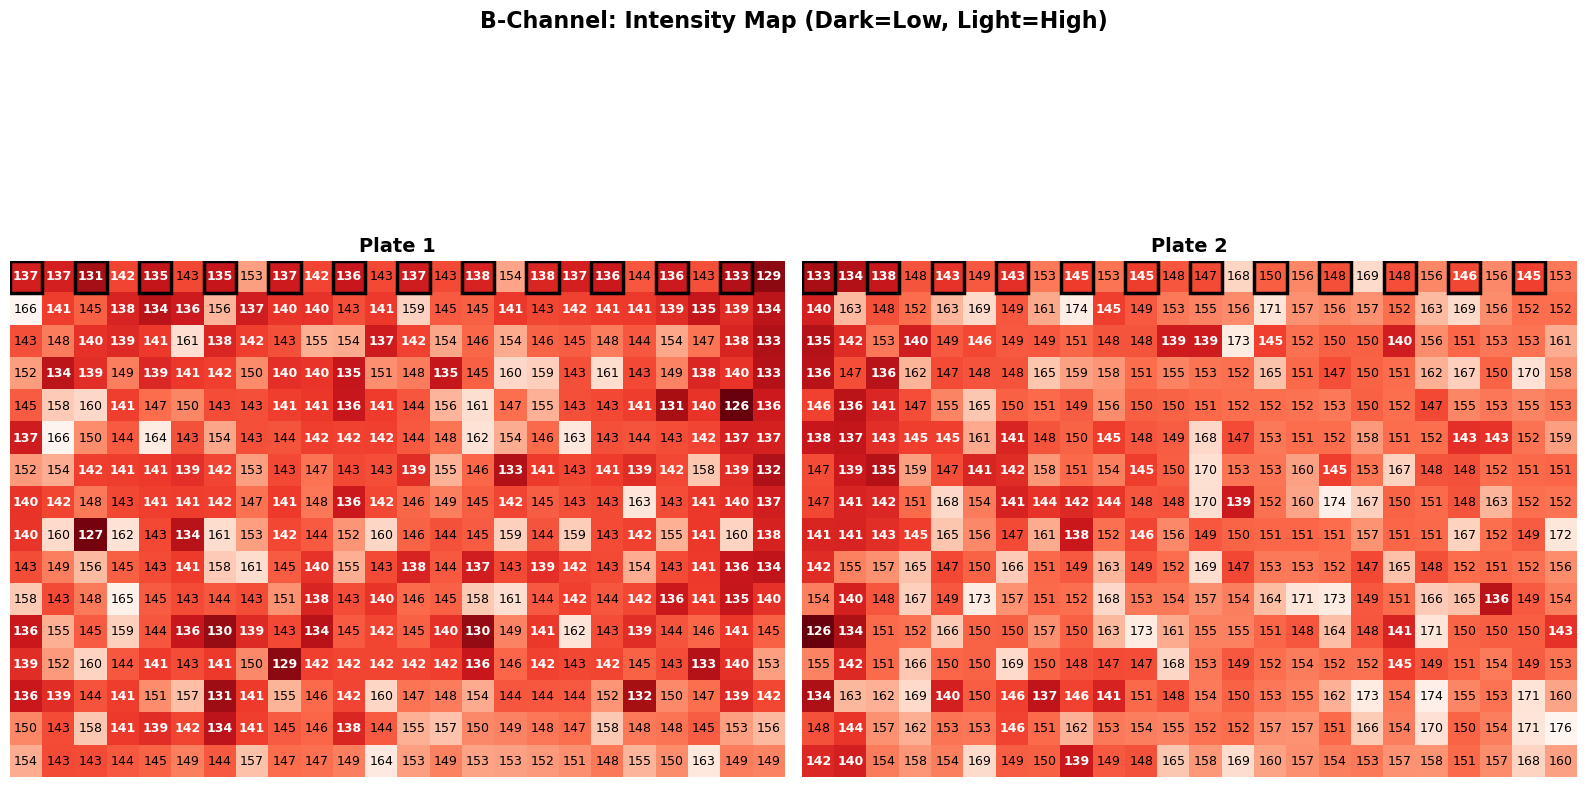

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- CONFIGURATION ---
data_dir = '/Users/astr/Documents/Pigments/ScanQuantif'
# Update this list to match the plates you actually loaded
plates_to_plot = [
    {'prefix': '0617_Red_12', 'num': '1', 'label': 'Plate 1', 'layout': 'type_A'},
    {'prefix': '0617_Red_12', 'num': '2', 'label': 'Plate 2', 'layout': 'type_A'},
]     
channels = ['R', 'G', 'B']

# --- HELPER: LOAD DATA FOR ONE PLATE ---
def load_plate_matrix(prefix, num, channel, data_dir):
    filename = f"{data_dir}/{prefix}_Plate{num}_{channel}.csv"
    try:
        df = pd.read_csv(filename, header=None)
        return df.to_numpy().reshape(16, 24)
    except FileNotFoundError:
        print(f"Missing: {filename}")
        return None

# --- HELPER: GET TAGS (Copy your existing logic) ---
def get_tags_layout(layout_type):
    tags = np.full((16, 24), 2, dtype=int) # Default 2 (Lake)
    if layout_type == 'type_A': # Even wells row 1
        tags[0, ::2] = 1 # Control
        tags[0, 1::2] = 0 # Sample
        tags[1:, :] = 0   # Rest Sample
    elif layout_type == 'type_B': # First 2 rows full control
        tags[:2, :] = 1
        tags[2:, :] = 0
    # Add other types if needed, defaulting to Type A for this demo if unknown
    return tags

# --- PLOTTING LOOP ---
for ch in channels:
    fig, axes = plt.subplots(1, len(plates_to_plot), figsize=(8 * len(plates_to_plot), 10))
    if len(plates_to_plot) == 1:
        axes = [axes]
    
    fig.suptitle(f'{ch}-Channel: Intensity Map (Dark=Low, Light=High)', fontsize=16, fontweight='bold')
    
    for idx, p_info in enumerate(plates_to_plot):
        ax = axes[idx]
        prefix = p_info['prefix']
        num = p_info['num']
        label = p_info['label']
        layout = p_info['layout']
        
        # 1. Load Data
        data = load_plate_matrix(prefix, num, ch, data_dir)
        if data is None:
            ax.text(0.5, 0.5, "Data Missing", ha='center', va='center', fontsize=20, color='red')
            ax.set_title(f"{label} (Missing)")
            ax.axis('off')
            continue
            
        # 2. Get Tags
        tags = get_tags_layout(layout)
        
        # 3. Normalize Data for Colormap (0 to 1)
        # Handle case where all values are identical
        v_min, v_max = data.min(), data.max()
        if v_max > v_min:
            norm_data = (data - v_min) / (v_max - v_min)
        else:
            norm_data = np.zeros_like(data)
            
        # 4. Apply Colormap (Reds_r: Low=Dark Red, High=Light Red/White)
        cmap = plt.get_cmap('Reds_r') 
        rgba_image = cmap(norm_data) # Shape (16, 24, 4)
        
        # 5. Plot the Heatmap
        ax.imshow(rgba_image)
        ax.set_title(f"{label}", fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # 6. Add Black Borders to Controls
        mask_ctrl = (tags == 1)
        # Iterate through control positions to draw rectangles
        ctrl_indices = np.argwhere(mask_ctrl)
        for i, j in ctrl_indices:
            rect = plt.Rectangle(
                (j - 0.5, i - 0.5), # Bottom-left corner (x, y)
                1, 1,               # Width, Height
                fill=False,         # Transparent fill
                edgecolor='black',  # Black border
                linewidth=2.5       # Thick line
            )
            ax.add_patch(rect)
        
        # 7. Add Text Overlay
        for i in range(16):
            for j in range(24):
                tag = tags[i, j]
                if tag == 2: # Lake/Ignored -> No text
                    continue
                
                val = int(np.round(data[i, j]))
                txt = str(val)
                
                # Auto-contrast text: White on dark backgrounds, Black on light
                # Since Low Value = Dark Red, use white text for low values
                if val < (v_min + 0.4 * (v_max - v_min)):
                    t_color = 'white'
                    font_weight = 'bold'
                else:
                    t_color = 'black'
                    font_weight = 'normal'
                
                ax.text(j, i, txt, ha='center', va='center', 
                        fontsize=9, color=t_color, fontweight=font_weight)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


The bimodal shape of histogramms could simply come from plates variability.
**==> important to plot data per plate, comparison of data from different plates is sketchy**

Not super convincing, but lets keep going. Made a clean pipe on the side with only confirmed/useful chunks of code, tested with new plates (purple controls) to normalize with blank. The idea here is to compute a mean background value per channel based on control wells:

From these 3 extractions, we want to compute the mean intnsity of control wells per channel. The wells used as control are:
- TO_empty => plate 1
- LakeCtrl: 
    * Plate 1: corners
    * Plate 2: l1+l2+l4+l5  
- D2Ext plate 1: 
    * check diff corners/controls/main >> 
    > take all if representative/take values that make sense

In [ ]:
# --- CONFIGURATION ---
data_dir = '/Users/astr/Documents/Pigments/ScanQuantif'
channels = ['R', 'G', 'B']

# Define the scans and the specific wells to include for background calculation
# Format: {'prefix': '...', 'plate': '...', 'selection': ...}
# Selection can be:
#   - 'all': Takes all 384 wells
#   - 'lines': [list of row indices, 0-based]
#   - 'indices': [list of flat indices 0-383]

background_sources = [
    # 1. 0619_T0_empty_corr => Plate 1 (All wells)
    {
        'prefix': '0619_T0_empty_corr',
        'plate': '1',
        'selection': 'all'
    },
    # 2. 0622_Vio_LakeCtrl => Plate 1 (Corners: 0, 23, 359, 383)
    {
        'prefix': '0622_Vio_LakeCtrl',
        'plate': '1',
        'selection': 'indices',
        'values': [0, 23, 359, 383]
    },
    # 3. 0622_Vio_LakeCtrl => Plate 2 (Lines 1, 2, 4, 5)
    # Note: Python is 0-indexed. Line 1 = index 0.
    {
        'prefix': '0622_Vio_LakeCtrl',
        'plate': '2',
        'selection': 'lines',
        'values': [0, 1, 3, 4] 
    },
    # 4. 0622_Vio_Red_ => Plate 1 (All wells)
    # Assuming prefix ends with underscore or you meant '0622_Vio_Red_12'? 
    # Adjust prefix below if necessary.
    {
        'prefix': '0622_Vio_Red_',
        'plate': '1',
        'selection': 'all'
    }
]

# --- HELPER: GET WELL INDICES FROM SELECTION ---
def get_well_indices(selection_type, values=None):
    all_indices = np.arange(384)
    
    if selection_type == 'all':
        return all_indices
    
    elif selection_type == 'lines':
        # values is a list of row indices (0-15)
        # Convert row indices to flat indices (row * 24 + col)
        selected = []
        for r in values:
            start = r * 24
            end = start + 24
            selected.extend(range(start, end))
        return np.array(selected)
    
    elif selection_type == 'indices':
        return np.array(values)
    
    return np.array([])

# --- MAIN CALCULATION LOOP ---
background_means = {}

print("Calculating Background Means per Channel...\n")

for ch in channels:
    collected_values = []
    
    for source in background_sources:
        prefix = source['prefix']
        plate = source['plate']
        sel_type = source['selection']
        sel_vals = source.get('values', None)
        
        # Construct filename: {prefix}_Plate{plate}_{ch}.csv
        # Note: If your prefix already includes '_Plate', adjust this logic.
        # Assuming format: "0619_T0_empty_corr_Plate1_R.csv"
        filename = f"{prefix}_Plate{plate}_{ch}.csv"
        filepath = os.path.join(data_dir, filename)
        
        try:
            # Load data
            df = pd.read_csv(filepath, header=None)
            data = df.to_numpy().flatten()
            
            # Get specific indices
            indices = get_well_indices(sel_type, sel_vals)
            
            # Extract values
            well_values = data[indices]
            collected_values.extend(well_values)
            
            print(f"Loaded {filename}: {len(well_values)} wells selected.")
            
        except FileNotFoundError:
            print(f"WARNING: File not found -> {filename}")
        except Exception as e:
            print(f"ERROR processing {filename}: {e}")

    if collected_values:
        arr = np.array(collected_values)
        mean_val = np.mean(arr)
        std_val = np.std(arr)
        background_means[ch] = mean_val
        
        print(f"--> {ch}-Channel Background Mean: {mean_val:.2f} (Std: {std_val:.2f}, Count: {len(arr)})")
    else:
        print(f"--> {ch}-Channel: NO DATA COLLECTED!")
        background_means[ch] = None

print("\n--- Final Background Values (I0) ---")
for ch, val in background_means.items():
    if val is not None:
        print(f"{ch}: {val:.2f}")
    else:
        print(f"{ch}: Undefined")

The blank values are sometimes lower than actual sample values, which is not to much of an issue but still, I questioned the relevance of what I was doing and asked ChatGPT for a feedback on all of the pipe. 
**Conclusion**: we are not too bad, but it might be interesting to correct for background relatively to location on the plate.

### Changement de programme...

After rethinking of the methodology, it seems better to actually compute a blank per well and channel, to have a least a tentative of correction for spatial variability. 

At this stage, RGB values of control plates should already have been extracted and stored in the correct folder !

In [4]:
# --- CONFIGURATION ---
data_dir = '/Users/astr/Documents/Pigments/ScanQuantif/Background_Matrices'
channels = ['R', 'G', 'B']

# Define the two control sources to average
# We assume these plates are FULL controls (all 384 wells are valid background)
control_sources = [
    {'prefix': '0702_Combined_Stacks_CORRECTED', 'plate': '1'},
    {'prefix': '0702_Combined_Stacks_CORRECTED', 'plate': '2'}
    #{'prefix': '0619_T0_empty_corr', 'plate': '1'},
    #{'prefix': '0622_Vio_Red_', 'plate': '1'} # Verify this prefix matches your file exactly
]

# Output storage
I0_matrices = {} # Will store {'R': matrix, 'G': matrix, 'B': matrix}

print("Computing Spatial Background Matrix (I0) per well...\n")

for ch in channels:
    all_plate_data = []
    
    for source in control_sources:
        prefix = source['prefix']
        plate = source['plate']
        filename = f"{prefix}_Plate{plate}_{ch}.csv"
        filepath = os.path.join(data_dir, filename)
        
        try:
            # Load CSV (16x24)
            df = pd.read_csv(filepath, header=None)
            data = df.to_numpy() # Shape: (16, 24)
            
            if data.shape != (16, 24):
                print(f"WARNING: {filename} has unexpected shape {data.shape}. Skipping.")
                continue
                
            all_plate_data.append(data)
            print(f"Loaded {filename} ({ch}-channel)")
            
        except FileNotFoundError:
            print(f"ERROR: File not found -> {filename}")
        except Exception as e:
            print(f"ERROR processing {filename}: {e}")

    if len(all_plate_data) > 0:
        # Stack all loaded plates along a new axis (e.g., shape becomes [2, 16, 24])
        stack = np.stack(all_plate_data, axis=0)
        
        # Compute mean along axis 0 (average the plates together)
        # Result shape: (16, 24)
        i0_matrix = np.mean(stack, axis=0)
        
        I0_matrices[ch] = i0_matrix
        
        print(f"--> {ch}-Channel I0 Matrix computed from {len(all_plate_data)} plates.")
        print(f"    Global Mean: {np.mean(i0_matrix):.2f} | Range: [{np.min(i0_matrix):.2f} - {np.max(i0_matrix):.2f}]")
    else:
        print(f"--> {ch}-Channel: FAILED to create matrix (no data).")
        I0_matrices[ch] = None

# --- SAVE MATRICES FOR LATER USE ---
# We save them as CSVs so you can load them into your analysis script later
output_folder = data_dir    #os.path.join(data_dir, 'Background_Matrices')
os.makedirs(output_folder, exist_ok=True)

print(f"\nSaving I0 matrices to: {output_folder}")
for ch, matrix in I0_matrices.items():
    if matrix is not None:
        save_path = os.path.join(output_folder, f'I0_Matrix_{ch}.csv')
        pd.DataFrame(matrix).to_csv(save_path, index=False, header=False)
        print(f"Saved: {save_path}")

print("\nDone! You can now load these CSVs to normalize your sample plates well-by-well.")

Computing Spatial Background Matrix (I0) per well...

Loaded 0702_Combined_Stacks_CORRECTED_Plate1_R.csv (R-channel)
Loaded 0702_Combined_Stacks_CORRECTED_Plate2_R.csv (R-channel)
--> R-Channel I0 Matrix computed from 2 plates.
    Global Mean: 170.64 | Range: [164.78 - 185.66]
Loaded 0702_Combined_Stacks_CORRECTED_Plate1_G.csv (G-channel)
Loaded 0702_Combined_Stacks_CORRECTED_Plate2_G.csv (G-channel)
--> G-Channel I0 Matrix computed from 2 plates.
    Global Mean: 161.60 | Range: [155.35 - 177.14]
Loaded 0702_Combined_Stacks_CORRECTED_Plate1_B.csv (B-channel)
Loaded 0702_Combined_Stacks_CORRECTED_Plate2_B.csv (B-channel)
--> B-Channel I0 Matrix computed from 2 plates.
    Global Mean: 167.15 | Range: [159.13 - 185.29]

Saving I0 matrices to: /Users/astr/Documents/Pigments/ScanQuantif/Background_Matrices
Saved: /Users/astr/Documents/Pigments/ScanQuantif/Background_Matrices/I0_Matrix_R.csv
Saved: /Users/astr/Documents/Pigments/ScanQuantif/Background_Matrices/I0_Matrix_G.csv
Saved: /User

Now, it just feels better to plot a heatmap of these values to make sure they look around reasonable values.

In [16]:
def plot_plate_heatmap(csv_path, layout_type='none', title=None, data_type='RGB'):
    """
    Plots a 16x24 heatmap from a CSV file.
    
    Parameters:
    - csv_path: Full path to the CSV file.
    - layout_type: 'type_A', 'type_B', 'type_C', 'type_D', or 'none'.
    - title: Custom title.
    - data_type: 'RGB' (Integers, Dark=Low) or 'OD' (3 decimals, Dark=High).
    """
    
    # 1. Load Data
    try:
        df = pd.read_csv(csv_path, header=None)
        data = df.to_numpy().reshape(16, 24)
    except FileNotFoundError:
        print(f"Error: File not found at {csv_path}")
        return
    except Exception as e:
        print(f"Error loading file: {e}")
        return

    # 2. Get Tags (for borders)
    tags = np.full((16, 24), -1, dtype=int)
    if layout_type == 'type_A':
        tags[0, ::2] = 1
    elif layout_type == 'type_B':
        tags[:2, :] = 1
    elif layout_type == 'type_C':
        tags[0, :] = 1
        tags[1, ::2] = 1
    elif layout_type == 'type_D':
        tags[0, :] = 1

    # 3. Normalize Data for Colormap (0 to 1)
    v_min, v_max = data.min(), data.max()
    if v_max > v_min:
        norm_data = (data - v_min) / (v_max - v_min)
    else:
        norm_data = np.zeros_like(data)

    # 4. Select Colormap based on Data Type
    if data_type == 'OD':
        # OD: Low Value (No pigment) = Light, High Value (Pigment) = Dark
        cmap = plt.get_cmap('Reds') 
        # In 'Reds', 0.0 is white, 1.0 is dark red.
    else:
        # RGB: Low Value (Dark) = Dark Red, High Value (Bright) = Light/White
        cmap = plt.get_cmap('Reds_r') 
        # In 'Reds_r', 0.0 is dark red, 1.0 is white.

    rgba_image = cmap(norm_data)

    # 5. Create Plot
    plt.figure(figsize=(12, 8))
    plt.imshow(rgba_image)
    
    if title is None:
        title = f"Heatmap: {csv_path.split('/')[-1]}"
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')

    # 6. Add Black Borders to Controls
    if layout_type != 'none':
        ctrl_indices = np.argwhere(tags == 1)
        for i, j in ctrl_indices:
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                 fill=False, edgecolor='black', linewidth=2.5)
            plt.gca().add_patch(rect)

    # 7. Add Text Overlay with Dynamic Formatting & Color
    for i in range(16):
        for j in range(24):
            val = data[i, j]
            
            # --- Format Text ---
            if data_type == 'OD':
                txt = f"{val:.3f}"
                # --- Text Color for OD ---
                # High OD = Dark Background -> White Text
                # Low OD = Light Background -> Black Text
                # Threshold: If normalized value > 0.4 (approx mid-range), make text white
                if norm_data[i, j] > 0.4: 
                    t_color = 'white'
                    f_weight = 'bold'
                else:
                    t_color = 'black'
                    f_weight = 'normal'
            else:
                # --- Format & Color for RGB ---
                txt = str(int(np.round(val)))
                # Low Value = Dark Background -> White Text
                if val < (v_min + 0.4 * (v_max - v_min)):
                    t_color = 'white'
                    f_weight = 'bold'
                else:
                    t_color = 'black'
                    f_weight = 'normal'
            
            plt.text(j, i, txt, ha='center', va='center', 
                     fontsize=8, color=t_color, fontweight=f_weight)

    plt.tight_layout()
    plt.show()

# --- EXAMPLE USAGE ---

# 1. Plot RGB Data (Dark=Low, Light=High)
# plot_plate_heatmap('.../0617_Red_12_Plate1_R.csv', layout_type='type_A', data_type='RGB')

# 2. Plot OD Data (Light=Low, Dark=High)
# plot_plate_heatmap('.../OD_output/OD_0617_Red_12_Plate1_R.csv', layout_type='type_A', data_type='OD')

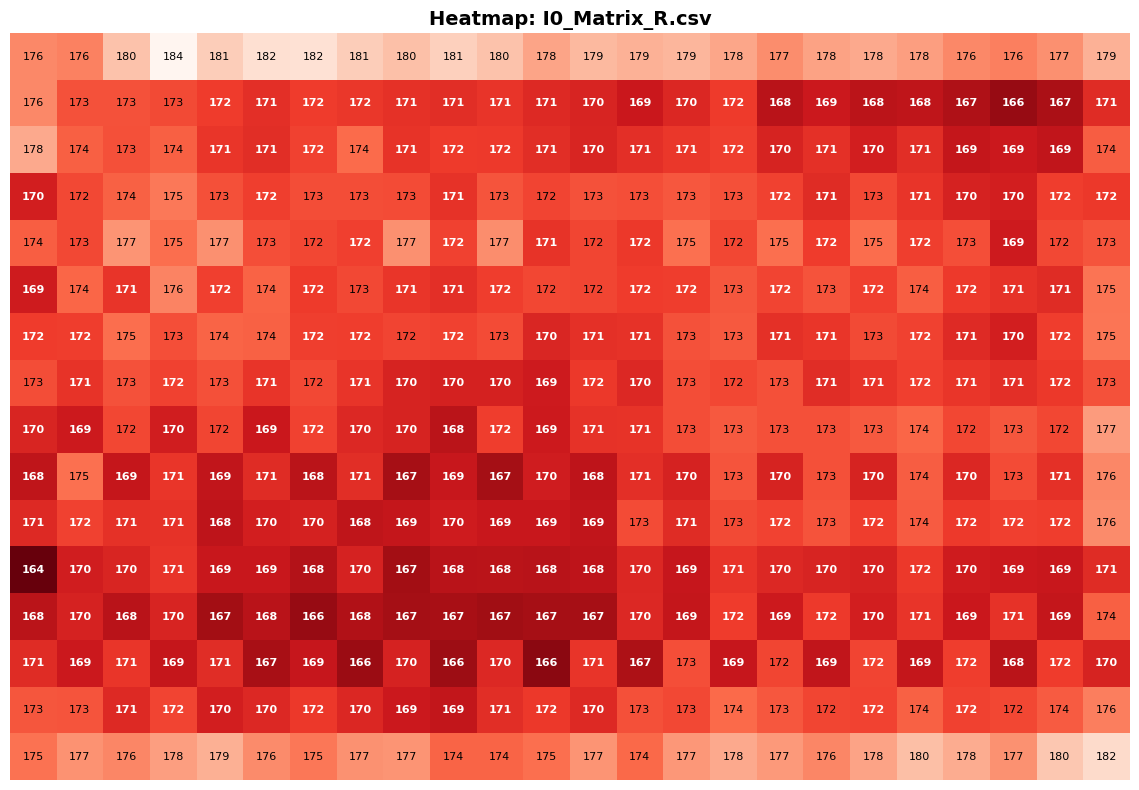

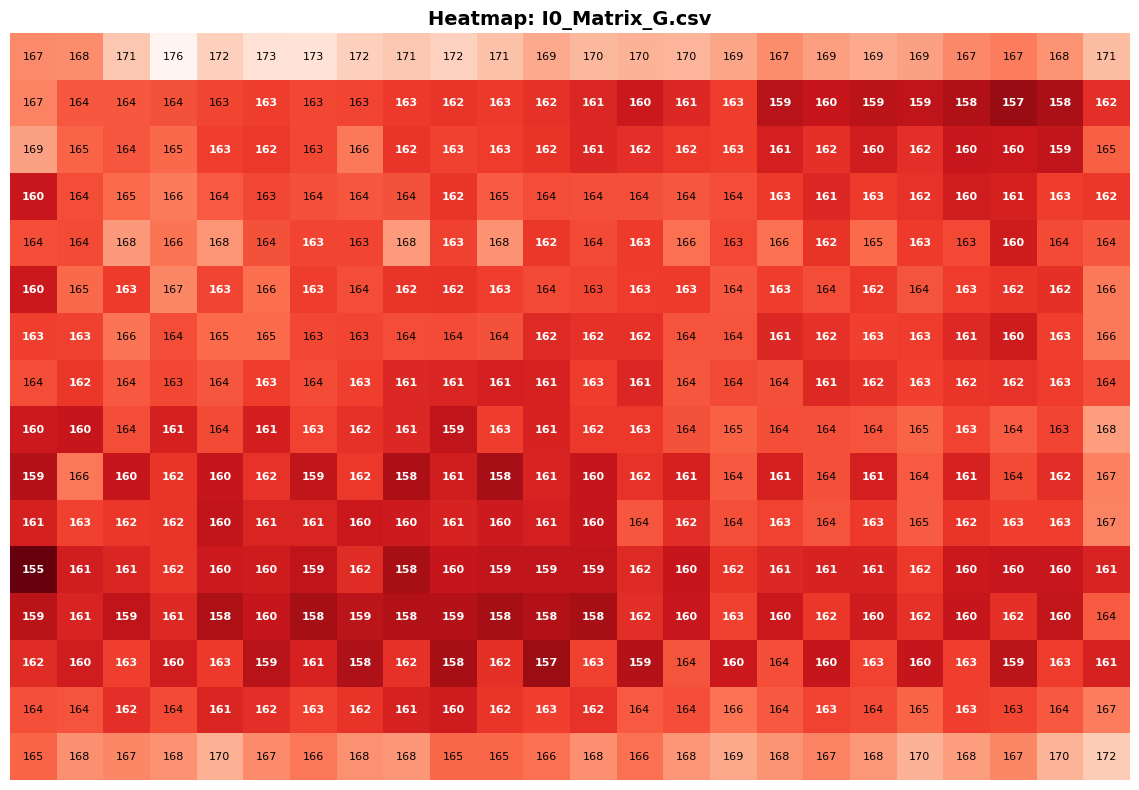

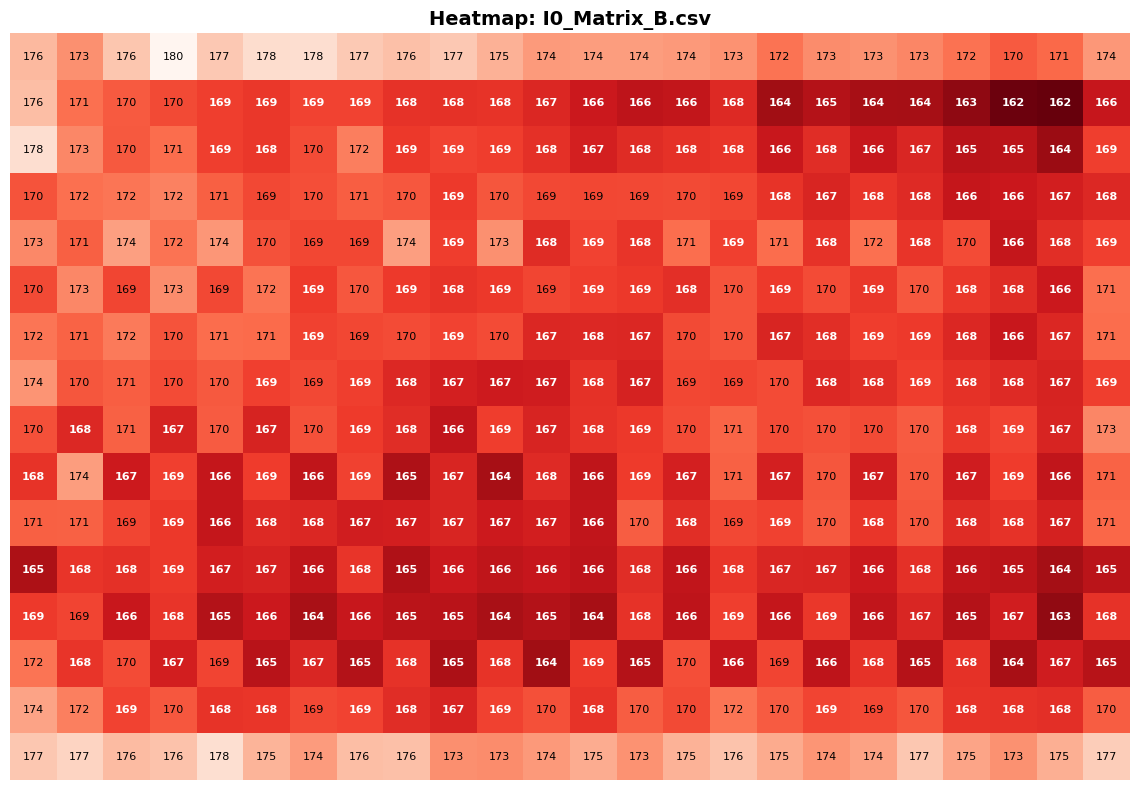

In [17]:
plot_plate_heatmap('/Users/astr/Documents/Pigments/ScanQuantif/Background_Matrices/I0_Matrix_R.csv', layout_type='none', data_type='RGB')
plot_plate_heatmap('/Users/astr/Documents/Pigments/ScanQuantif/Background_Matrices/I0_Matrix_G.csv', layout_type='none', data_type='RGB')
plot_plate_heatmap('/Users/astr/Documents/Pigments/ScanQuantif/Background_Matrices/I0_Matrix_B.csv', layout_type='none', data_type='RGB')

### Function to apply BLL on sample data per channel

In [11]:
def compute_od_matrix(sample_prefix, sample_plate_num, 
                      background_dir='/Users/astr/Documents/Pigments/ScanQuantif/Background_Matrices',
                      data_dir='/Users/astr/Documents/Pigments/ScanQuantif',
                      output_dir='/Users/astr/Documents/Pigments/ScanQuantif/OD_output',
                      plot_results=True):
    """
    Computes the Optical Density (OD) matrix for a specific sample plate using spatial background correction.
    
    Formula: OD = -log10( Sample_Intensity / I0_Intensity )
    
    Parameters:
    - sample_prefix: Prefix of the sample file (e.g., '0617_Red_12')
    - sample_plate_num: Plate number (e.g., '1' or '2')
    - background_dir: Folder containing I0_Matrix_R.csv, etc.
    - data_dir: Folder containing the sample CSVs.
    - output_dir: Folder where OD CSVs will be saved.
    - plot_results: If True, displays a heatmap of the computed OD.
    
    Returns:
    - od_matrices: Dictionary {'R': matrix, 'G': matrix, 'B': matrix}
    """
    
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    channels = ['R', 'G', 'B']
    od_matrices = {}
    
    print(f"Computing OD for {sample_prefix}_Plate{sample_plate_num}...\n")

    for ch in channels:
        # 1. Define File Paths
        sample_file = f"{sample_prefix}_Plate{sample_plate_num}_{ch}.csv"
        sample_path = os.path.join(data_dir, sample_file)
        
        i0_file = f"I0_Matrix_{ch}.csv"
        i0_path = os.path.join(background_dir, i0_file)
        
        # 2. Load Data
        try:
            # Load Sample
            df_sample = pd.read_csv(sample_path, header=None)
            data_sample = df_sample.to_numpy()
            
            # Load Background (I0)
            df_i0 = pd.read_csv(i0_path, header=None)
            data_i0 = df_i0.to_numpy()
            
            if data_sample.shape != data_i0.shape:
                print(f"ERROR: Shape mismatch for {ch}-channel. Sample: {data_sample.shape}, I0: {data_i0.shape}")
                continue
                
        except FileNotFoundError as e:
            print(f"ERROR: File not found for {ch}-channel. {e}")
            continue

        # 3. Apply Beer-Lambert Law
        # OD = -log10( I / I0 )
        # Add small epsilon to avoid division by zero or log(0)
        epsilon = 1e-6
        
        # Element-wise division
        ratio = (data_sample + epsilon) / (data_i0 + epsilon)
        
        # Compute OD
        od_matrix = -np.log10(ratio)
        
        # Handle negative ODs (if sample is brighter than background, usually noise)
        # We keep them for now to see the distribution, but you can clip to 0 if preferred:
        # od_matrix = np.clip(od_matrix, 0, None) 
        
        od_matrices[ch] = od_matrix
        
        # 4. Save Result
        output_filename = f"OD_{sample_prefix}_Plate{sample_plate_num}_{ch}.csv"
        output_path = os.path.join(output_dir, output_filename)
        
        pd.DataFrame(od_matrix).to_csv(output_path, index=False, header=False)
        
        print(f"--> {ch}-Channel: OD computed. Range [{od_matrix.min():.3f} - {od_matrix.max():.3f}]. Saved to {output_filename}")

    print(f"\nDone! OD matrices saved in: {output_dir}")
    return od_matrices

# --- EXAMPLE USAGE ---
# Uncomment and run this line to test with your data:
# compute_od_matrix('0617_Red_12', '1')

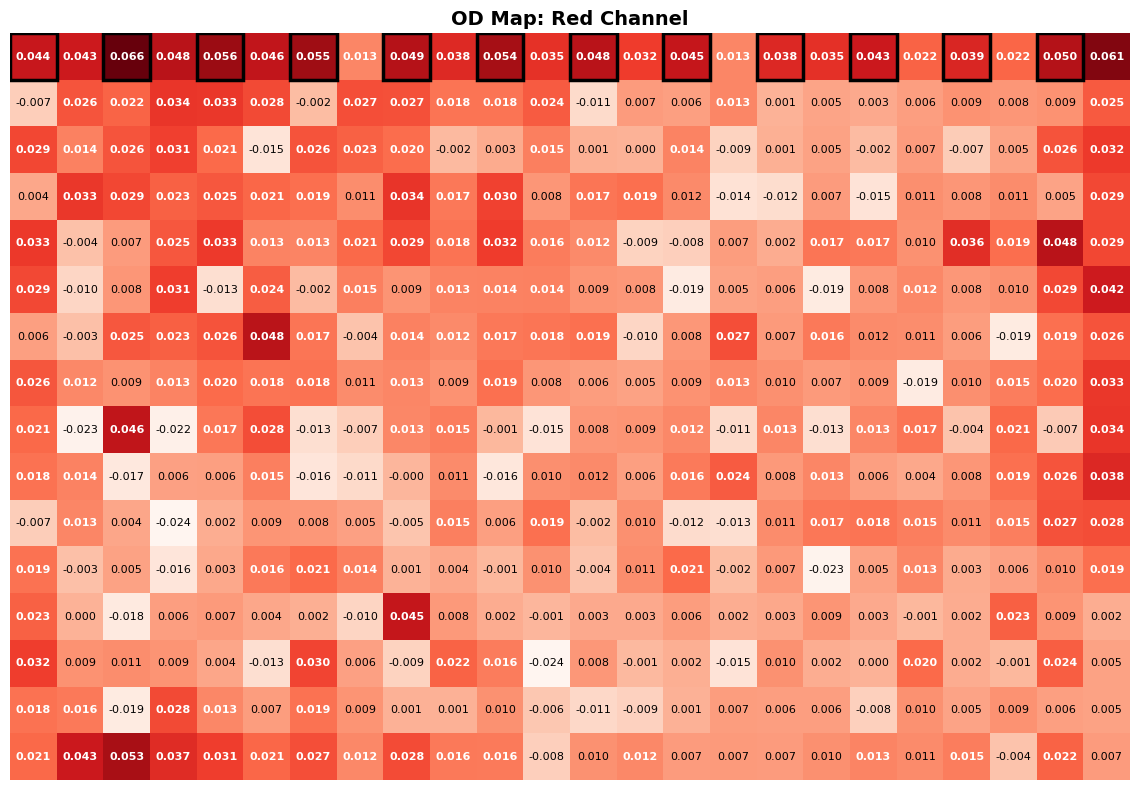

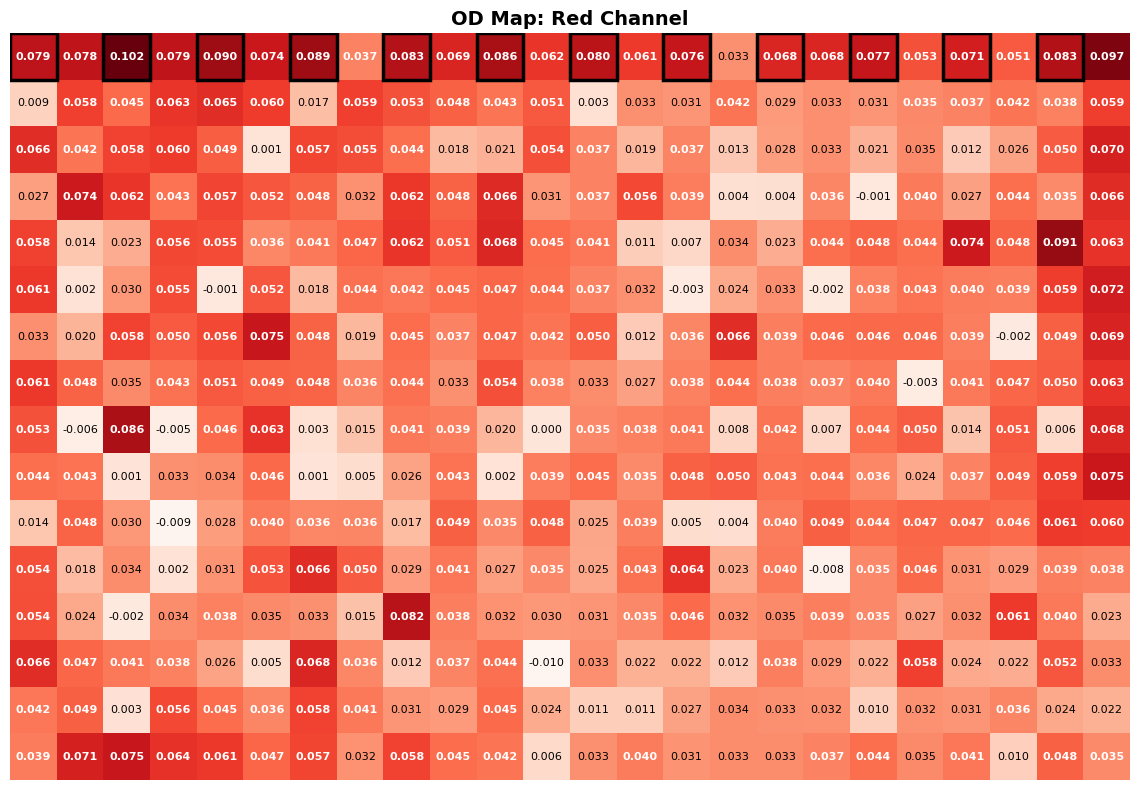

In [19]:
#compute_od_matrix('0617_Red_12', '1')
plot_plate_heatmap(
    '/Users/astr/Documents/Pigments/ScanQuantif/OD_output/OD_0617_Red_12_Plate1_R.csv', 
    layout_type='type_A', 
    title="OD Map: Red Channel",
    data_type='OD'
)

plot_plate_heatmap(
    '/Users/astr/Documents/Pigments/ScanQuantif/OD_output/OD_0617_Red_12_Plate1_G.csv', 
    layout_type='type_A', 
    title="OD Map: Red Channel",
    data_type='OD'
)

Yeahaaaa
The green matrix does transmit the red intensity pretty well ! 

## Plotting !

We need to plot OD histograms per plate, as we saw that the red controls values differ from a plate to the other... And as we don't have as many controls as samples per plate and different amounts of controls trough the different plates, it is better to plot the frequencies instrad of counts. 

In [20]:
def plot_od_histograms(od_file_prefix, plate_num, layout_type='type_A', 
                       data_dir='/Users/astr/Documents/Pigments/ScanQuantif/OD_output',
                       bins=40):
    """
    Plots normalized frequency histograms of OD values for a single plate.
    Controls are shown in Red, Samples in Grey.
    
    Parameters:
    - od_file_prefix: Prefix of the OD files (e.g., 'OD_0617_Red_12')
    - plate_num: Plate number (e.g., '1')
    - layout_type: 'type_A', 'type_B', etc. (to identify controls)
    - data_dir: Folder containing the OD CSVs.
    - bins: Number of bins for the histogram.
    """
    
    channels = ['R', 'G', 'B']
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'OD Distribution: {od_file_prefix}_Plate{plate_num}\n(Normalized Frequency)', 
                 fontsize=16, fontweight='bold')
    
    # Helper to get tags (same logic as before)
    def get_tags(layout):
        tags = np.zeros(384, dtype=int) # 0=Sample, 1=Control
        if layout == 'type_A':
            tags[0:24:2] = 1
        elif layout == 'type_B':
            tags[0:48] = 1
        elif layout == 'type_C':
            tags[0:24] = 1
            tags[24:48:2] = 1
        elif layout == 'type_D':
            tags[0:24] = 1
        return tags

    tags = get_tags(layout_type)
    ctrl_mask = (tags == 1)
    samp_mask = (tags == 0) # Ignore 'Lake' (tag 2) for this plot

    for idx, ch in enumerate(channels):
        ax = axes[idx]
        filename = f"{od_file_prefix}_Plate{plate_num}_{ch}.csv"
        filepath = os.path.join(data_dir, filename)
        
        try:
            df = pd.read_csv(filepath, header=None)
            data = df.to_numpy().flatten()
            
            # Extract Control and Sample values
            controls = data[ctrl_mask]
            samples = data[samp_mask]
            
            # Filter out NaNs or infinite values if any
            controls = controls[np.isfinite(controls)]
            samples = samples[np.isfinite(samples)]
            
            # Plot Histograms with Density=True (Normalizes to Frequency)
            # density=True ensures the area under the curve = 1, allowing comparison between groups of different sizes
            ax.hist(controls, bins=bins, density=True, alpha=0.7, 
                    color='#d62728', label='Controls', edgecolor='black', linewidth=0.5)
            
            ax.hist(samples, bins=bins, density=True, alpha=0.5, 
                    color='#7f7f7f', label='Samples', edgecolor='black', linewidth=0.5)
            
            ax.set_title(f'{ch}-Channel OD', fontsize=14)
            ax.set_xlabel('Optical Density (OD)')
            ax.set_ylabel('Frequency Density')
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            ax.legend(loc='upper right')
            
            # Add stats text box
            stats_text = (f"Ctrl Mean: {np.mean(controls):.3f}\n"
                          f"Samp Mean: {np.mean(samples):.3f}")
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
        except FileNotFoundError:
            ax.text(0.5, 0.5, f"Missing:\n{filename}", ha='center', va='center', color='red')
            ax.set_title(f'{ch}-Channel (Missing)')
            ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- EXAMPLE USAGE ---
# Call this function for each plate you want to analyze.
# You can put these calls in a loop in your main script.

# Example 1:
# plot_od_histograms('OD_0617_Red_12', '1', layout_type='type_A')

# Example 2:
# plot_od_histograms('OD_0622_Vio_LakeCtrl', '2', layout_type='type_B')

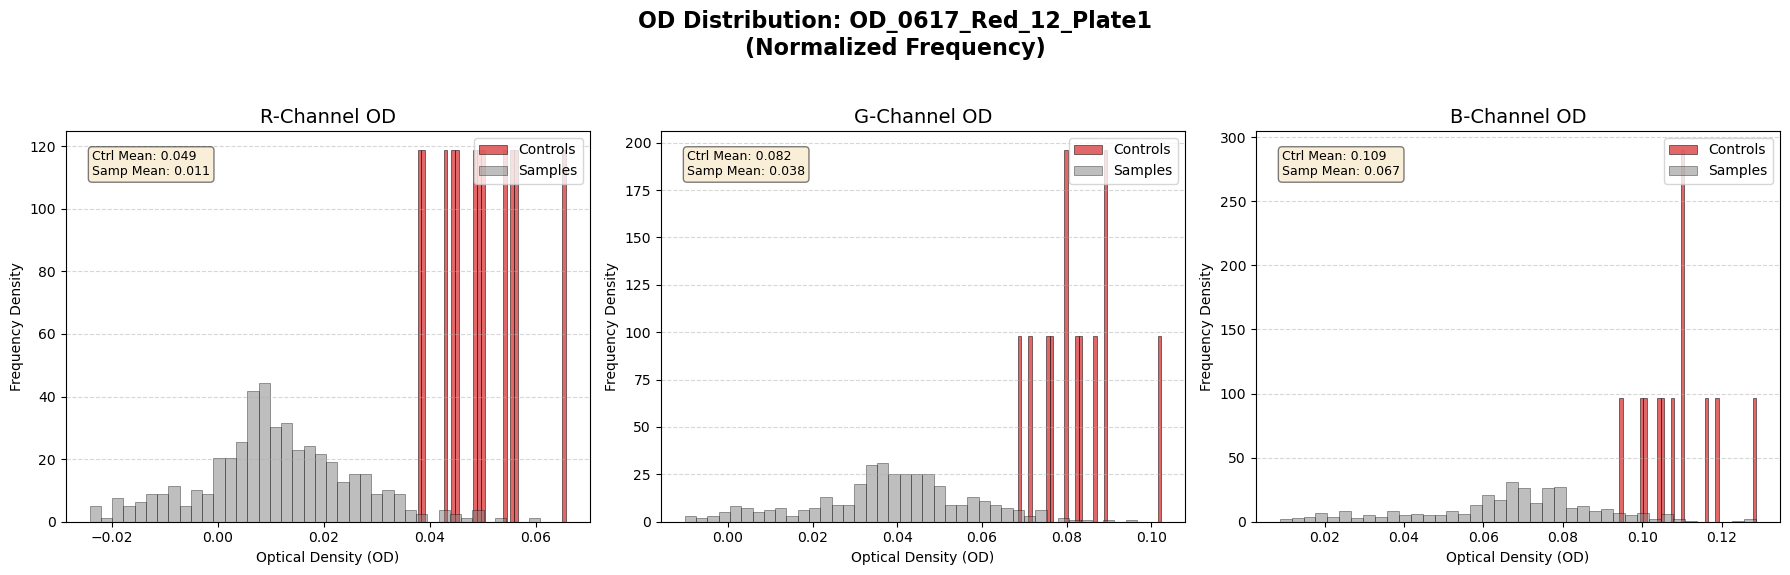

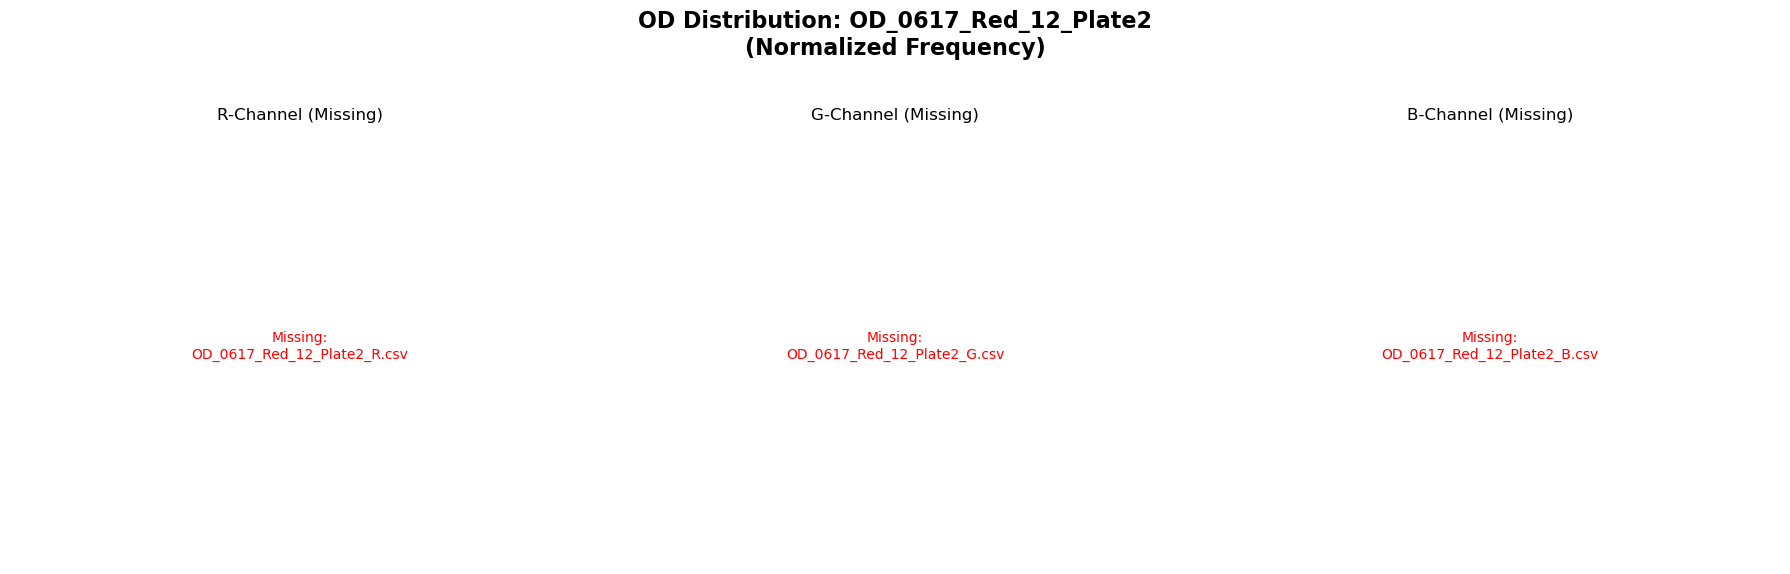

In [21]:
plot_od_histograms('OD_0617_Red_12', '1', layout_type='type_A')
plot_od_histograms('OD_0617_Red_12', '2', layout_type='type_A')